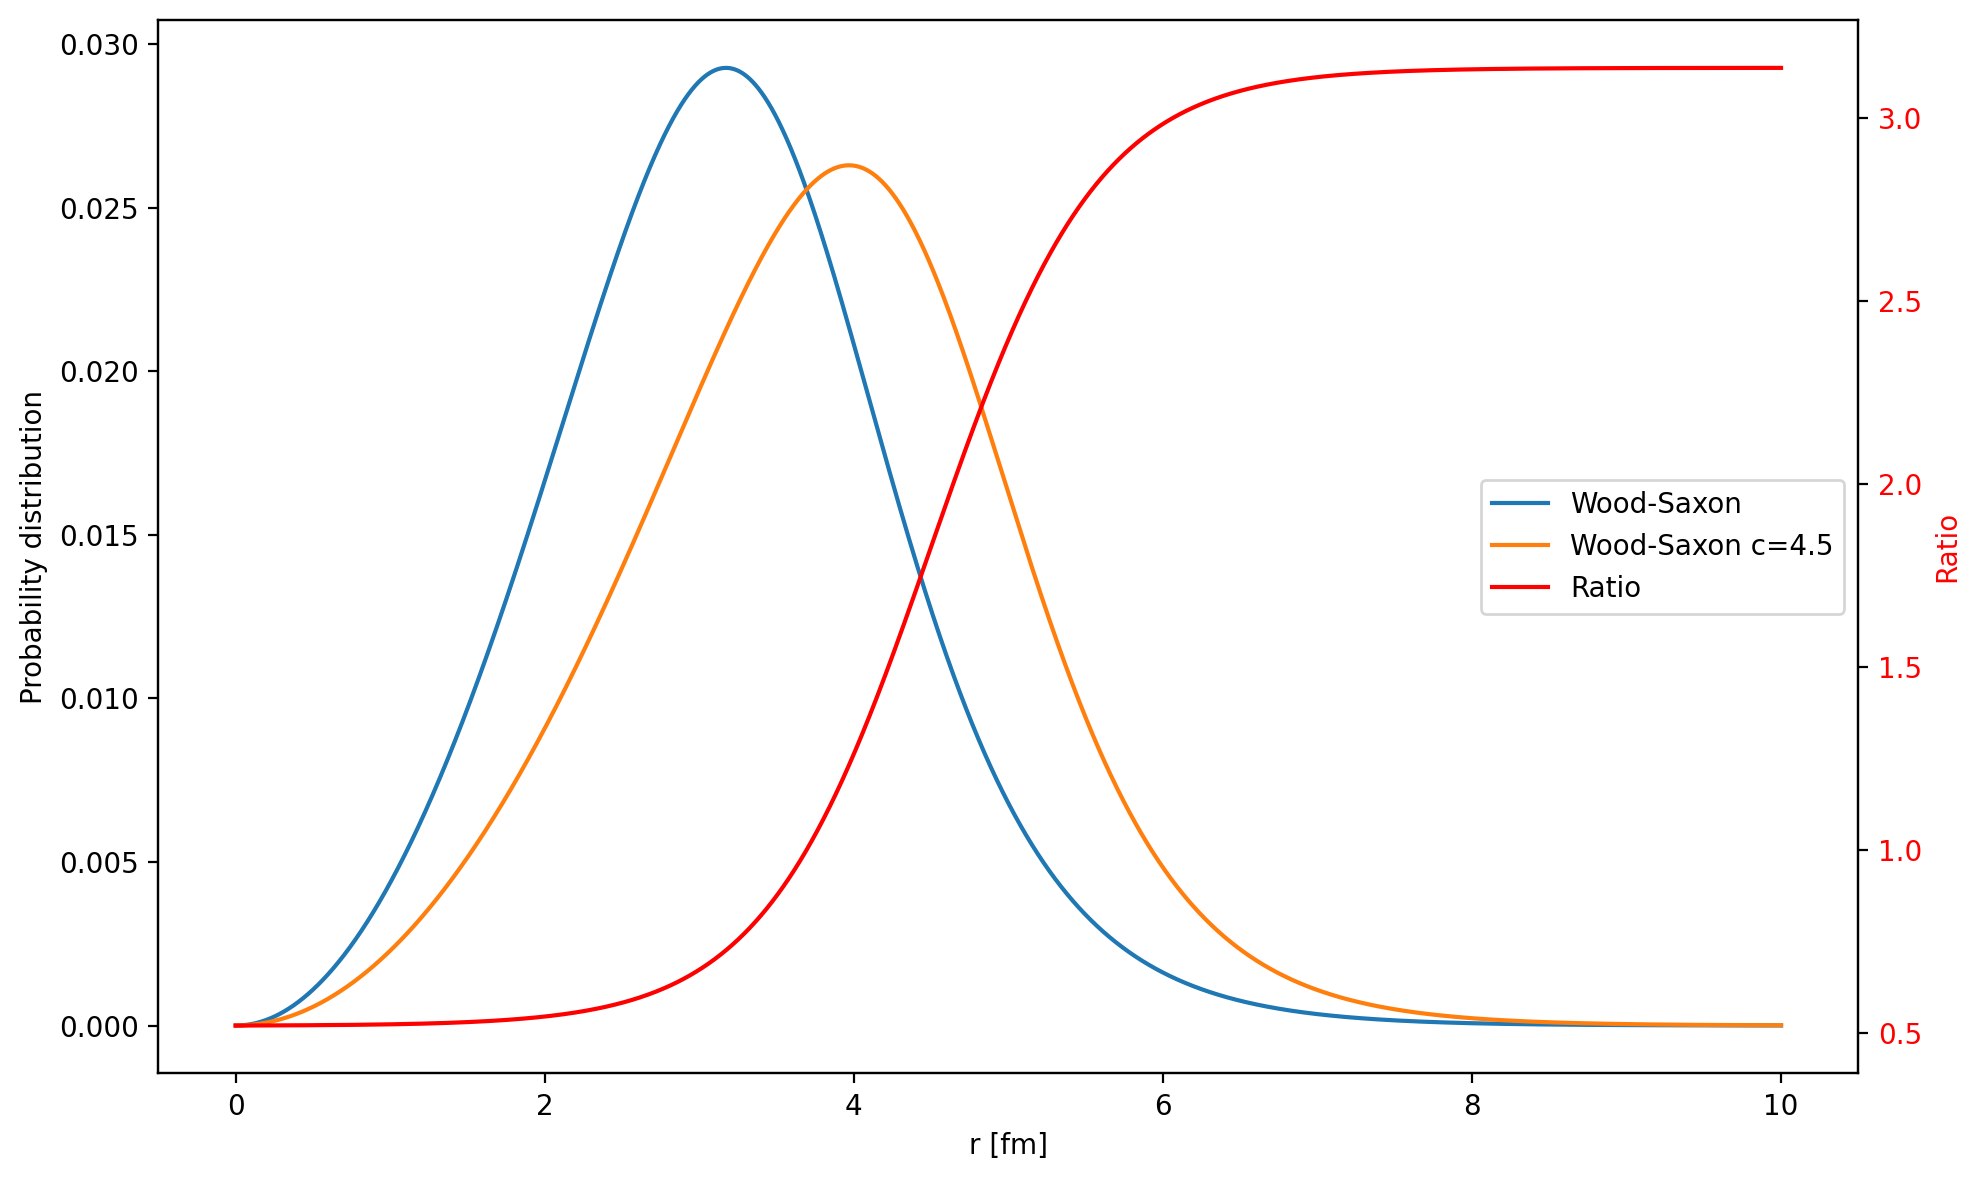

In [1]:
import numpy as np
import matplotlib.pyplot as plt

%config InlineBackend.figure_format = "retina"

cutoff = 0.7
tau = 0.12

c = 3.53
z = 0.54

R0 = 1.4
A = 40
R = R0*(A)**(1./3)
rmax = 3*R

hbarc = 1.973269804e-16
fermi = 1.e-15/hbarc

def WoodSaxon(r, c, z):
    norm = (3./(4*np.pi*c**3))*(1./(1 + (np.pi*z/c)**2))
    return norm/(1 + np.exp((r - c)/z))

def RtoKf(r):
    N = 22
    return (N*3*(np.pi**2)*WoodSaxon(r, c, z))**(1./3)/fermi

def KftoR(kf):
    N = 22
    norm = (3./(4*np.pi*c**3))*(1./(1 + (np.pi*z/c)**2))
    return c + z*np.log((3*norm*N*(np.pi**2))/(fermi*kf)**3 - 1)

plt.figure(figsize=(10, 6))
r = np.linspace(0, 10, 10000)
kf = RtoKf(r)
ws = WoodSaxon(r, c, z)
# plt.hist(kf, bins=100, weights=ws*r*r);
# plt.hist(r - KftoR(kf))
# plt.plot(r, kf)
plt.plot(r, ws*r*r, label='Wood-Saxon')
plt.plot(r, WoodSaxon(r, 4.5, z)*r*r, label='Wood-Saxon c=4.5')
ax = plt.gca()
ax2 = plt.gca().twinx()
ax2.plot(r, WoodSaxon(r, 4.5, z)/ws, color='red', label='Ratio')
ax2.set_ylabel('Ratio', color='red')
ax2.tick_params(axis='y', labelcolor='red')
#Displays both legends of ax and ax2 together
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines + lines2, labels + labels2, loc='center right')
ax.set_xlabel('r [fm]')
ax.set_ylabel('Probability distribution')
plt.tight_layout()

In [50]:
RtoKf(0)

np.float64(0.280353400016503)

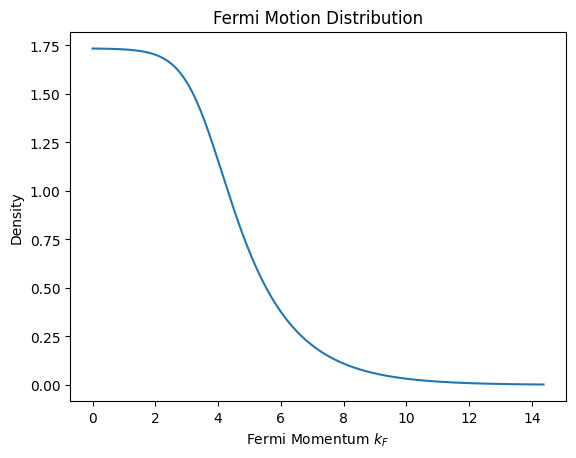

In [87]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

# Constants
c = 3.53  # Wood-Saxon radius parameter
z = 0.54  # Wood-Saxon diffuseness parameter
R0 = 1.4  # Nuclear radius constant
A = 40    # Mass number
R = R0 * A**(1/3)  # Nuclear radius
rmax = 3 * R  # Maximum radius for integration

# Wood-Saxon distribution
def WoodSaxon(r, c, z):
    return 1 / (1 + np.exp((r - c) / z))

# Normalize the Wood-Saxon distribution
def normalize_wood_saxon(c, z, rmax):
    integral, _ = quad(lambda r: 4 * np.pi * r**2 * WoodSaxon(r, c, z), 0, rmax)
    return A / integral

norm_factor = normalize_wood_saxon(c, z, rmax)

def normalized_wood_saxon(r):
    return norm_factor * WoodSaxon(r, c, z)

# Fermi momentum
def RtoKf(r):
    return (3 * np.pi**2 * normalized_wood_saxon(r))**(1/3)

# Generate data
r = np.linspace(0, rmax, 10000)
kf = RtoKf(r)
ws = normalized_wood_saxon(r)

# Plot histogram
plt.figure()
# plt.hist(kf, bins=100, weights=ws * r**2 * 4 * np.pi, density=True)
plt.plot(r, kf)
plt.xlabel('Fermi Momentum $k_F$')
plt.ylabel('Density')
plt.title('Fermi Motion Distribution')
plt.show()


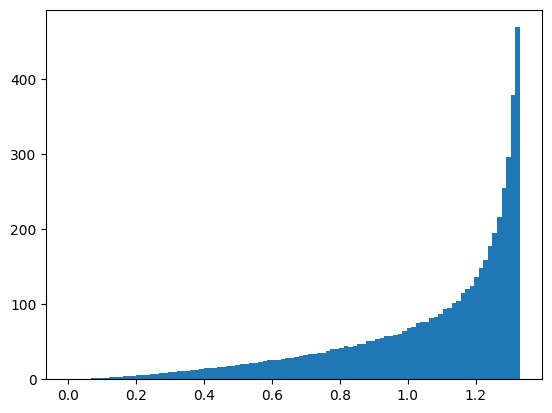

In [83]:
# Generate 1M values according to the Wood-Saxon distribution
n = 1000000
r = np.random.uniform(0, rmax, n)
kf = RtoKf(r)
ws = WoodSaxon(r, c, z)
plt.figure()
plt.hist(kf, bins=100, weights=ws*r*r);


In [2]:
import uproot
import polars as pl
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 18})

#Save CCQE events as parquet
with uproot.open("out_dump.root") as f:
    genie = f["genie_dump"]
    keys = genie.keys()
    loaded = {}
    for key in tqdm(keys):
        loaded[key] = genie[key].array(library="np")
    genie = pl.DataFrame(loaded)


with uproot.open('out.root') as f:
    cols = ['EventID', 'SubRun', 'Run', 'Ecalo', 'Elep_calo', 'Emu_range', 'Emu_mcs', 'Ee_calo', 'Pmu_x', 'Pmu_y', 'Pmu_z', 'Pe_x', 'Pe_y', 'Pe_z']
    reco = f['SystWeights'].arrays(cols, library='pd')
    reco = pl.from_pandas(reco)

    syst_id = f['SRGlobal/wgts.params.id'].array(library='np')[0]
    syst_nshifts = f['SRGlobal/wgts.params.nshifts'].array(library='np')[0]
    syst_name = f['SRGlobal/wgts.params.name'].array(library='np')[0]
    
    systs_header = pl.DataFrame({
        'id': syst_id,
        'nshifts': syst_nshifts,
        'name': syst_name
    })
    variations_all = None
    for syst in tqdm(systs_header.iter_rows(named=True), total=len(systs_header)):
        variations = f['SystWeights'][syst['name']].array(library='np')
        col_names = [f'{syst["name"]}_{i}' for i in range(syst['nshifts'])]
        variations = pl.from_numpy(variations, schema=col_names)
        if variations_all is None:
            variations_all = pl.concat([genie, reco, variations], how='horizontal')
        else:
            variations_all = pl.concat([variations_all, variations], how='horizontal')
    variations_ccqe = variations_all.filter(
        pl.col('proc') == '<QES - Weak[CC]>'
    )
    print(variations_ccqe)

100%|██████████| 2/2 [00:00<00:00,  4.14it/s]


shape: (261_211, 46)
┌──────┬─────┬───────────┬───────────┬───┬──────────────┬──────────────┬─────────────┬─────────────┐
│ isCC ┆ pdg ┆ lep_Px    ┆ lep_Py    ┆ … ┆ surface_thic ┆ surface_thic ┆ surface_thi ┆ surface_thi │
│ ---  ┆ --- ┆ ---       ┆ ---       ┆   ┆ kness_1      ┆ kness_2      ┆ ckness_3    ┆ ckness_4    │
│ i32  ┆ i32 ┆ f32       ┆ f32       ┆   ┆ ---          ┆ ---          ┆ ---         ┆ ---         │
│      ┆     ┆           ┆           ┆   ┆ f64          ┆ f64          ┆ f64         ┆ f64         │
╞══════╪═════╪═══════════╪═══════════╪═══╪══════════════╪══════════════╪═════════════╪═════════════╡
│ 1    ┆ 12  ┆ 0.167502  ┆ 0.226594  ┆ … ┆ 1.009973     ┆ 1.0          ┆ 0.982453    ┆ 0.960635    │
│ 1    ┆ 14  ┆ -0.092706 ┆ -0.242687 ┆ … ┆ 1.0484       ┆ 1.0          ┆ 0.942133    ┆ 0.887376    │
│ 1    ┆ 14  ┆ -1.154238 ┆ -0.759066 ┆ … ┆ 1.00799      ┆ 1.0          ┆ 0.984458    ┆ 0.964218    │
│ 1    ┆ 12  ┆ 0.184269  ┆ 0.188543  ┆ … ┆ 1.041042     ┆ 1.0         

/home/pgranger/.local/lib/python3.10/site-packages/polars/series/series.py:1464: RuntimeWarning: invalid value encountered in log
  lambda out: ufunc(*args, out=out, dtype=dtype_char, **kwargs),


258003.19882061495
259068.03847912236
261211.0
266759.94461934513


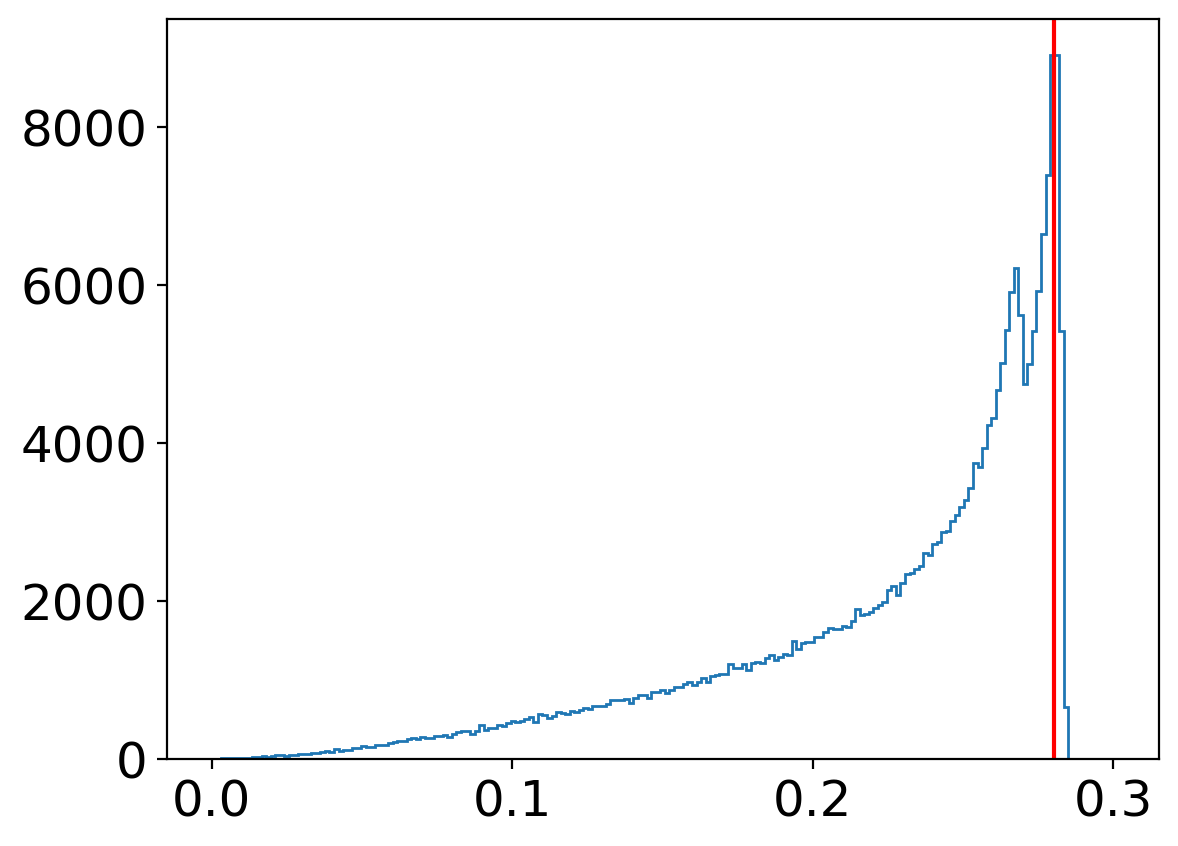

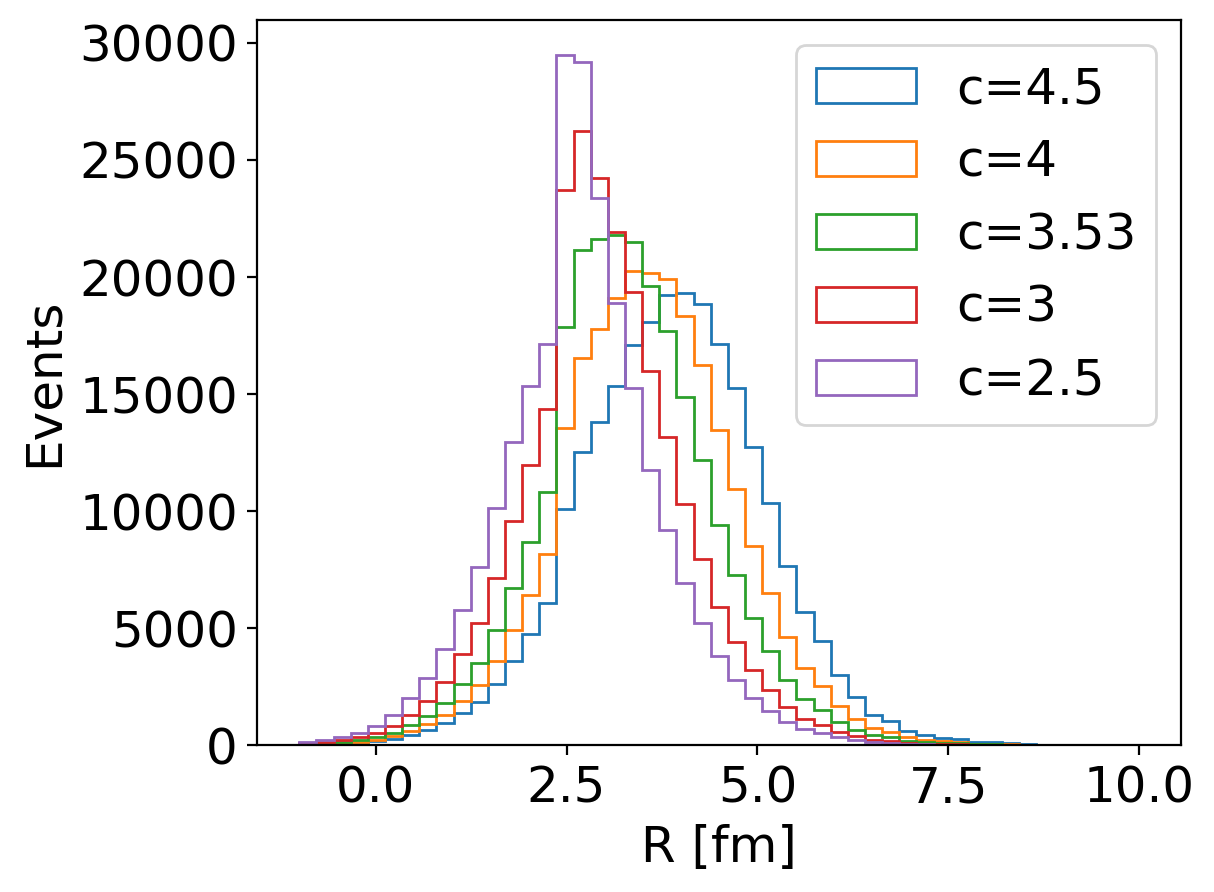

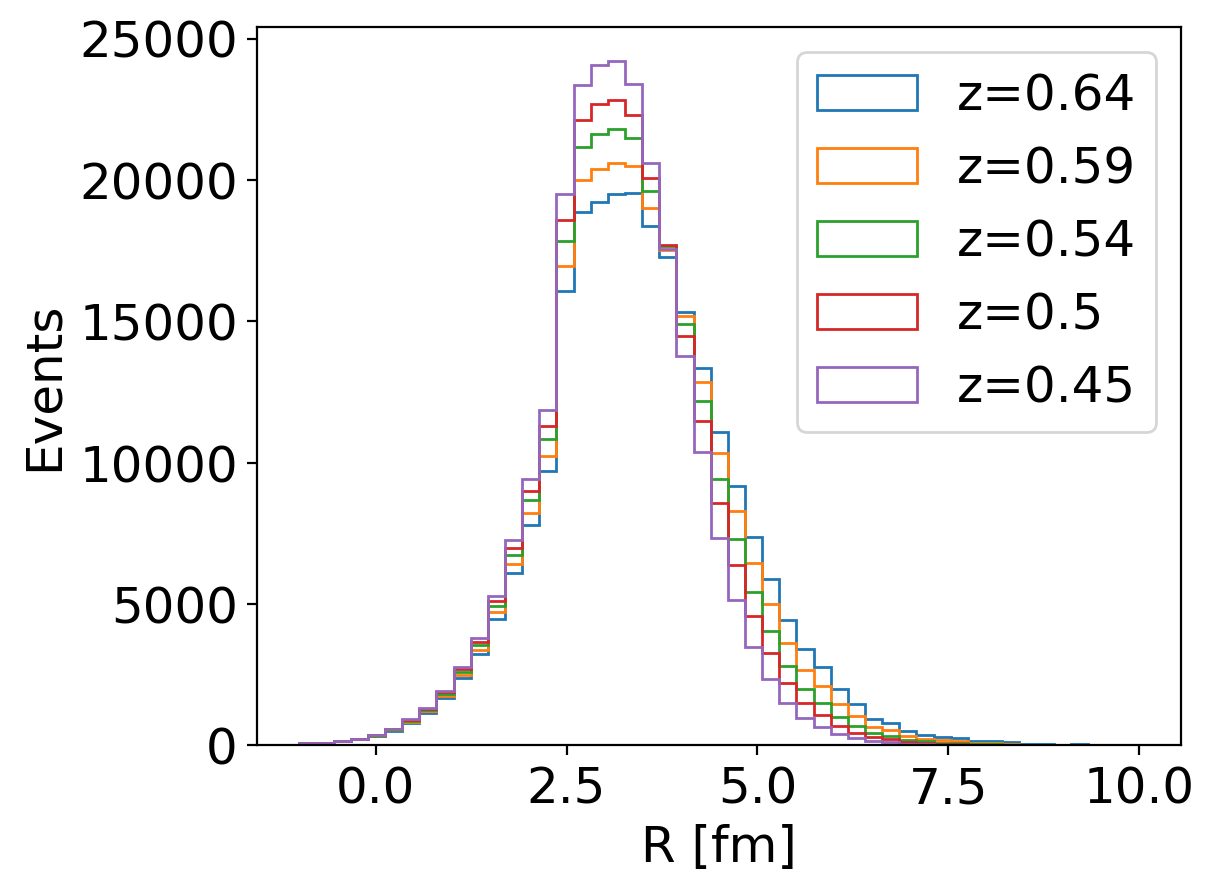

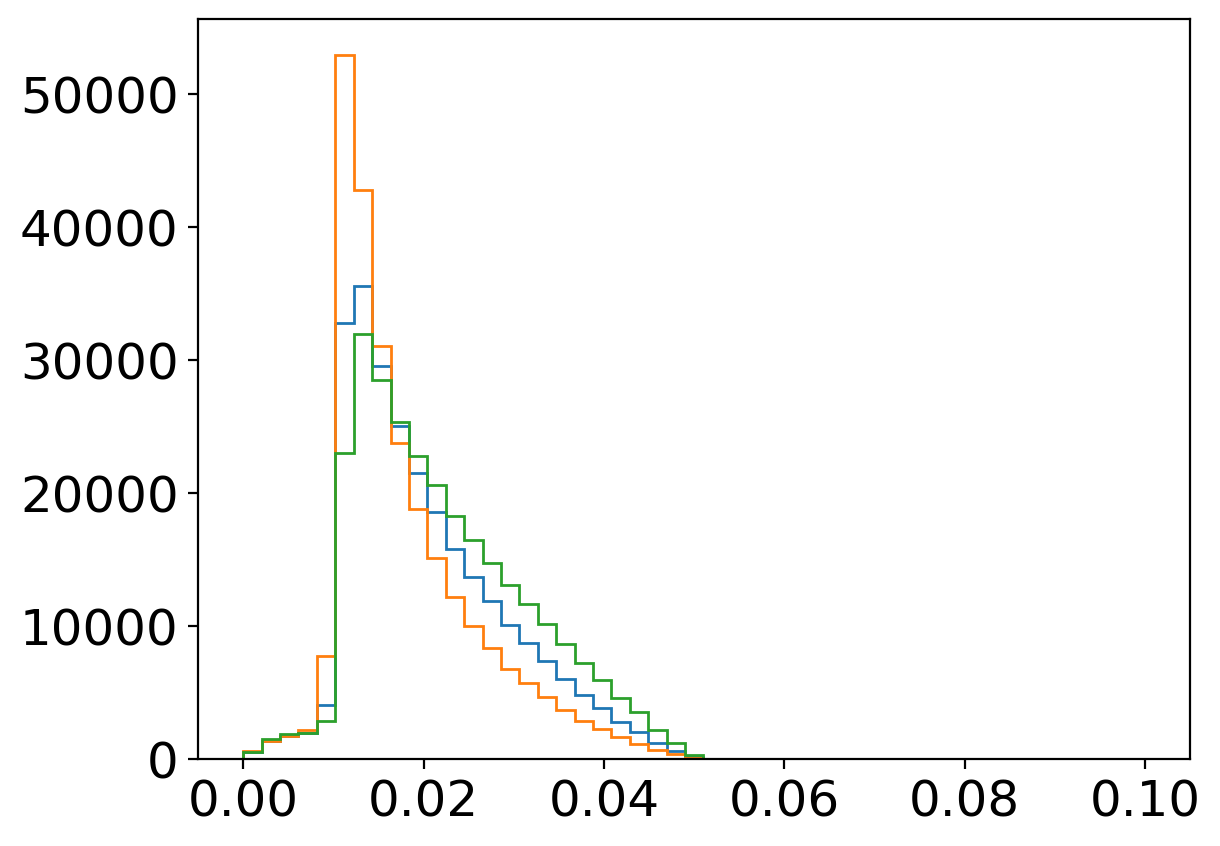

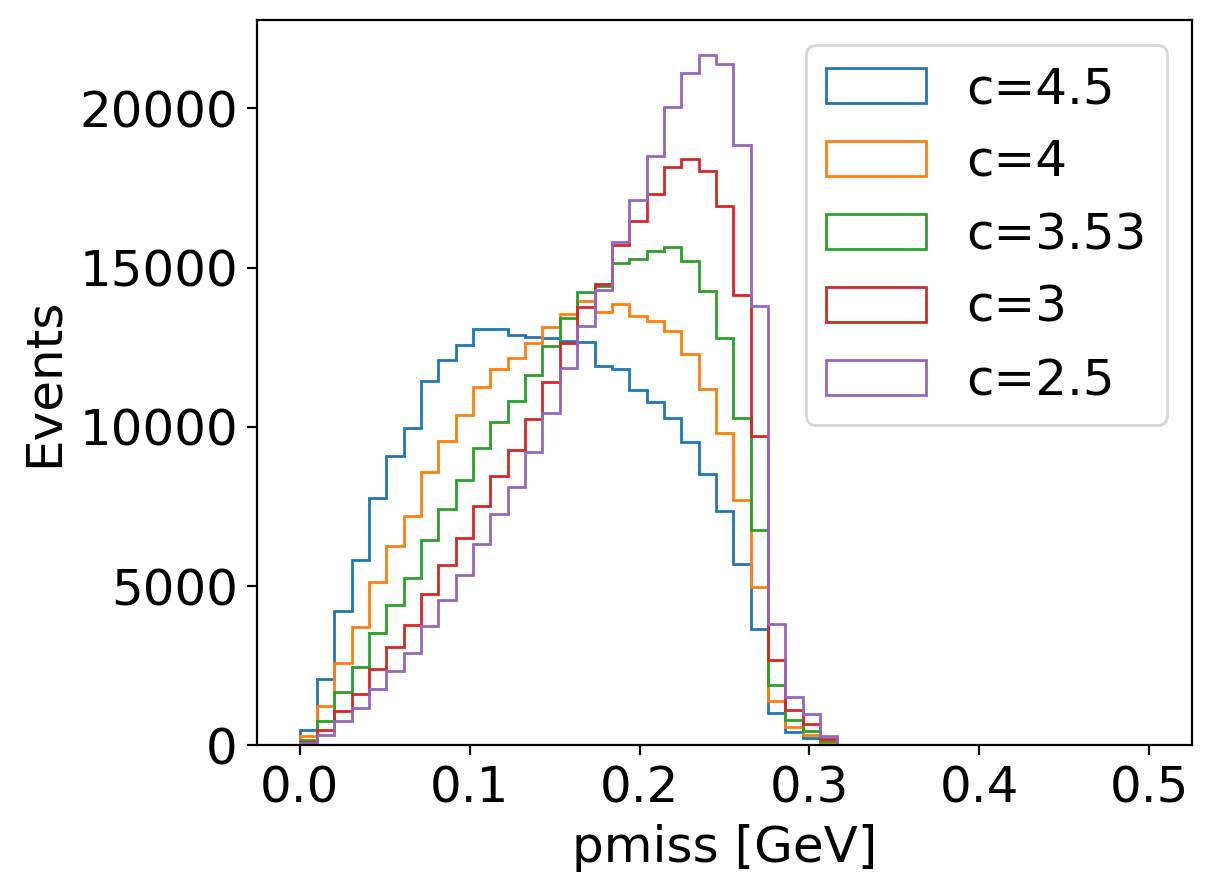

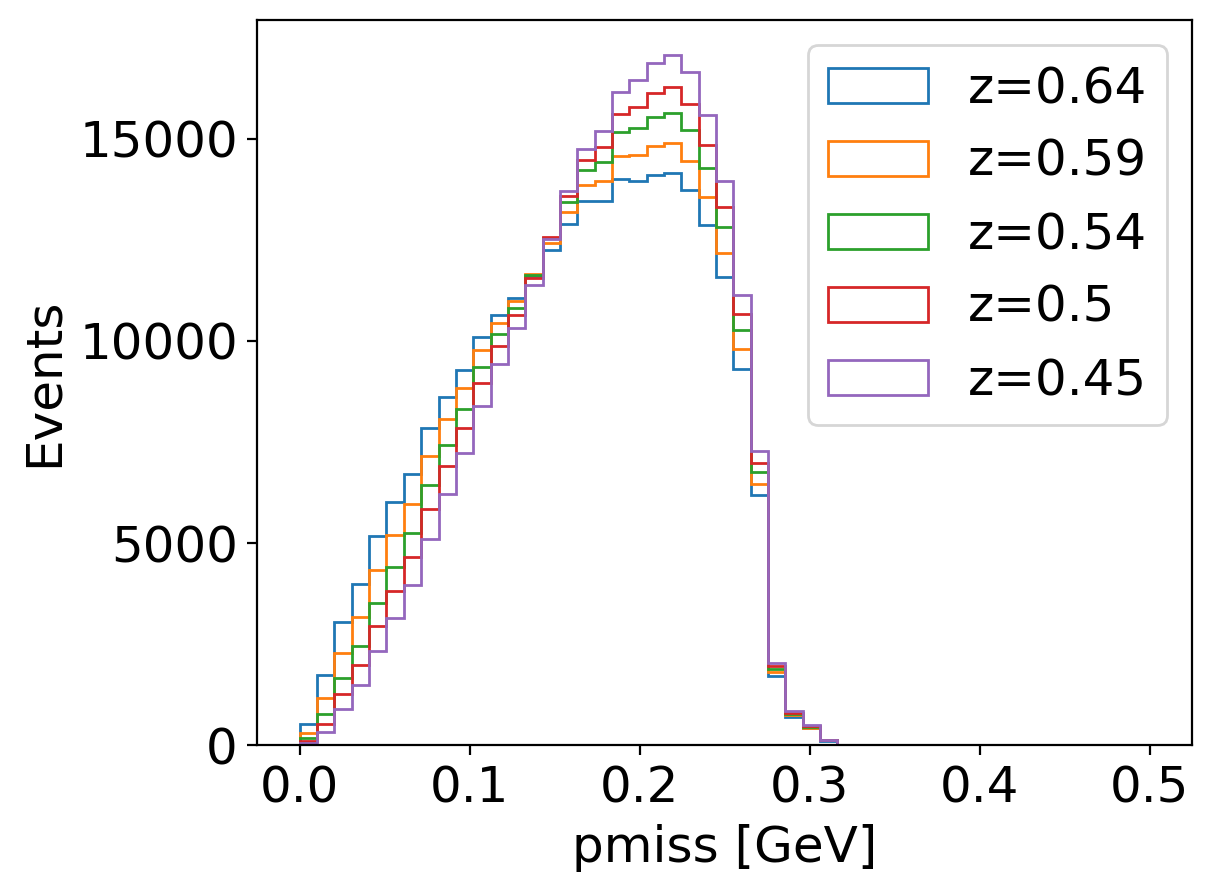

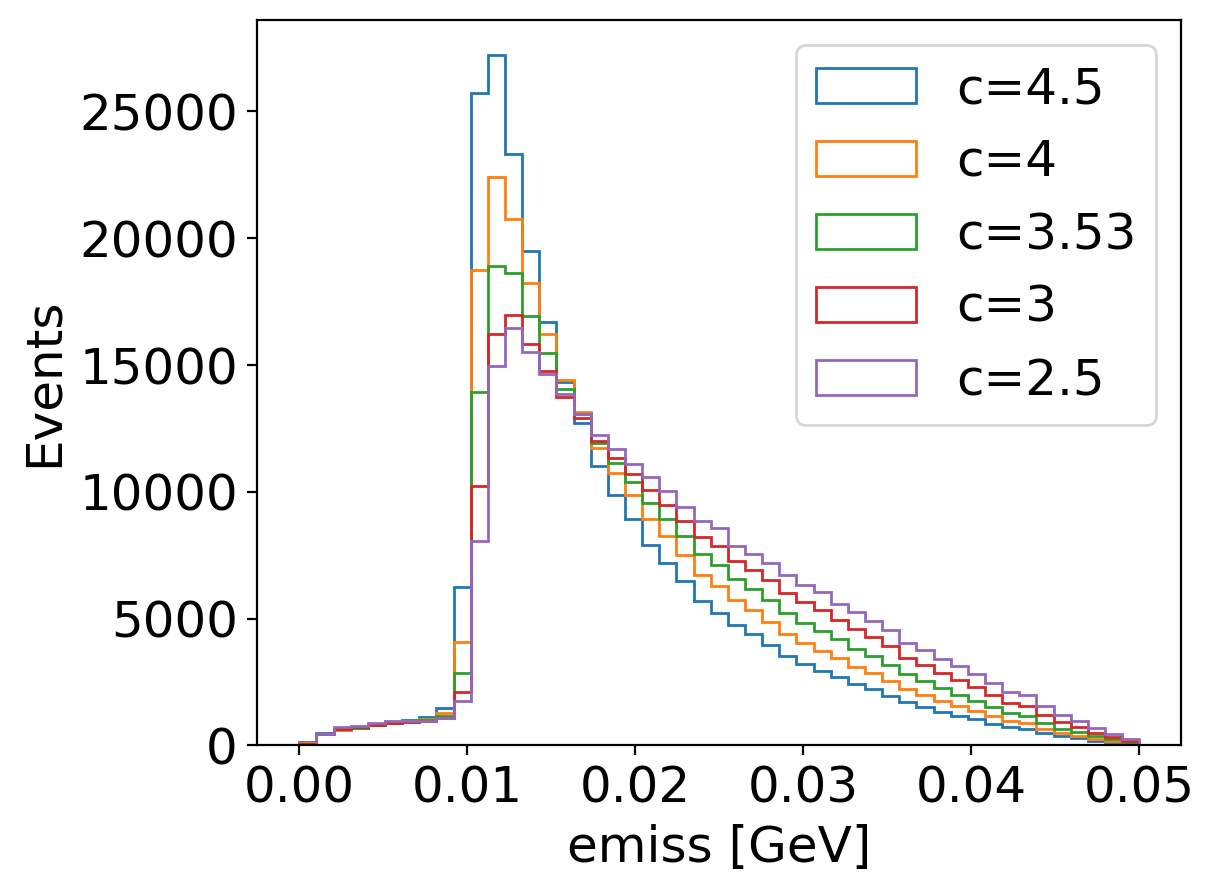

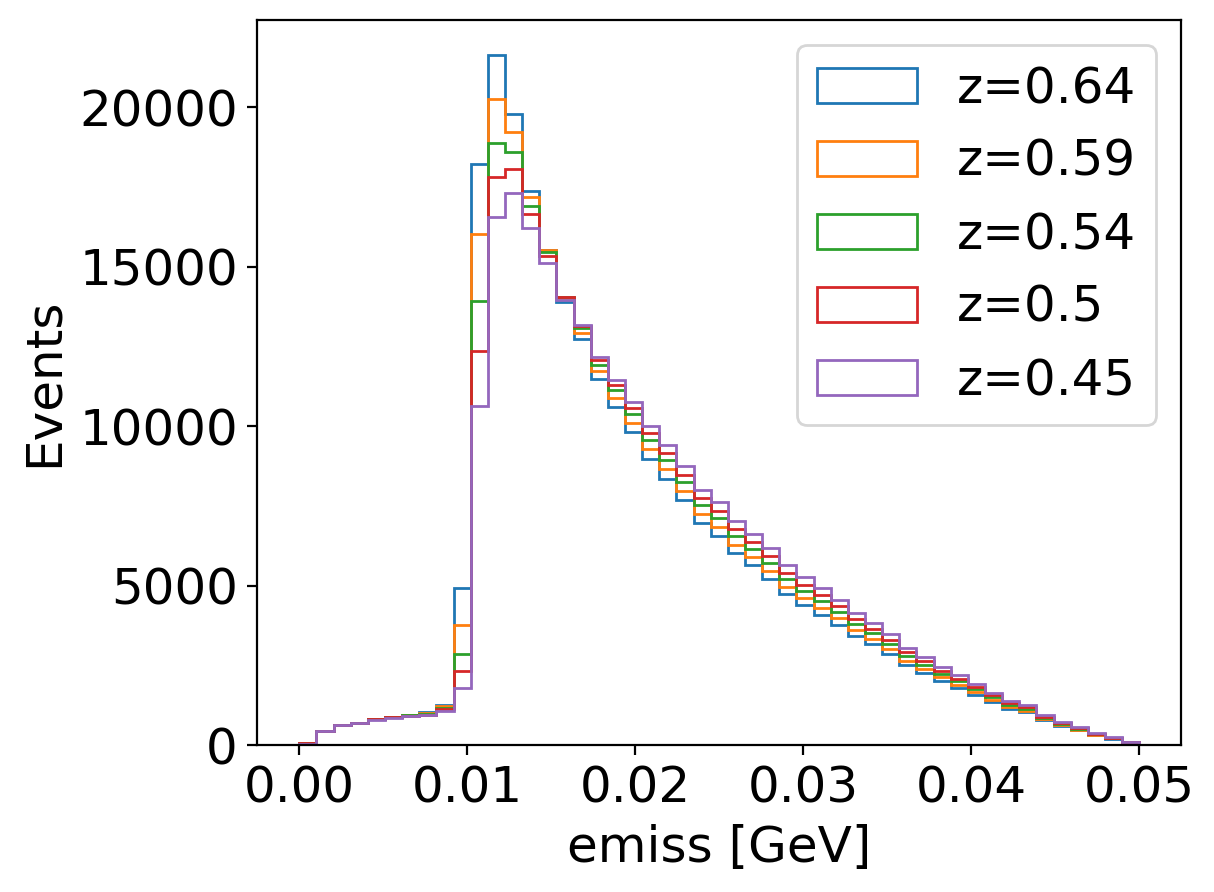

In [4]:
nucleon_mass = 0.93956542052
data = variations_ccqe.with_columns(
    pmiss = (pl.col('hitnuc_Px')**2 + pl.col('hitnuc_Py')**2 + pl.col('hitnuc_Pz')**2).sqrt(),
    emiss = nucleon_mass - pl.col('hitnuc_E') ,
).with_columns(
    KF = ((pl.col('emiss') + (pl.col('pmiss')**2 + nucleon_mass**2).sqrt() - 0.01)**2 - nucleon_mass**2).sqrt()
)

pbins = np.linspace(0, 0.30, 200)
plt.hist(data['KF'], pbins, histtype='step', label='KF');
plt.axvline(0.280353400016503, color='r')

c = 3.53
z = 0.54
hbarc = 1.973269804e-16
fermi = 1.e-15/hbarc
def KftoR(kf):
    N = 22
    norm = (3./(4*np.pi*c**3))*(1./(1 + (np.pi*z/c)**2))
    return c + z*np.log((3*norm*N*(np.pi**2))/(fermi*kf)**3 - 1)
plt.figure()
plt.hist(KftoR(data['KF']), bins=np.linspace(-1, 10, 50), histtype='step', label=f'c=4.5', weights=data['nucleus_radius_4'], linewidth=1);
plt.hist(KftoR(data['KF']), bins=np.linspace(-1, 10, 50), histtype='step', label=f'c=4', weights=data['nucleus_radius_3'], linewidth=1);
plt.hist(KftoR(data['KF']), bins=np.linspace(-1, 10, 50), histtype='step', label=f'c=3.53', weights=data['nucleus_radius_2'], linewidth=1);
plt.hist(KftoR(data['KF']), bins=np.linspace(-1, 10, 50), histtype='step', label=f'c=3', weights=data['nucleus_radius_1'], linewidth=1);
plt.hist(KftoR(data['KF']), bins=np.linspace(-1, 10, 50), histtype='step', label=f'c=2.5', weights=data['nucleus_radius_0'], linewidth=1);
print(np.sum(data['nucleus_radius_4'].to_numpy()))
print(np.sum(data['nucleus_radius_3'].to_numpy()))
print(np.sum(data['nucleus_radius_2'].to_numpy()))
print(np.sum(data['nucleus_radius_1'].to_numpy()))
plt.legend()
plt.xlabel('R [fm]')
plt.ylabel('Events')
plt.tight_layout()

plt.figure()
plt.hist(KftoR(data['KF']), bins=np.linspace(-1, 10, 50), histtype='step', label=f'z=0.64', weights=data['surface_thickness_4'], linewidth=1);
plt.hist(KftoR(data['KF']), bins=np.linspace(-1, 10, 50), histtype='step', label=f'z=0.59', weights=data['surface_thickness_3'], linewidth=1);
plt.hist(KftoR(data['KF']), bins=np.linspace(-1, 10, 50), histtype='step', label=f'z=0.54', weights=data['surface_thickness_2'], linewidth=1);
plt.hist(KftoR(data['KF']), bins=np.linspace(-1, 10, 50), histtype='step', label=f'z=0.5', weights=data['surface_thickness_1'], linewidth=1);
plt.hist(KftoR(data['KF']), bins=np.linspace(-1, 10, 50), histtype='step', label=f'z=0.45', weights=data['surface_thickness_0'], linewidth=1);
plt.legend()
plt.xlabel('R [fm]')
plt.ylabel('Events')
plt.tight_layout()



plt.figure()
plt.hist(data['emiss'], bins=np.linspace(0, 0.1, 50), histtype='step', label='R');
plt.hist(data['emiss'], bins=np.linspace(0, 0.1, 50), histtype='step', label='R', weights=data['nucleus_radius_4']);
plt.hist(data['emiss'], bins=np.linspace(0, 0.1, 50), histtype='step', label='R', weights=data['nucleus_radius_0']);
# plt.hist2d(KftoR(data['KF']), data['nucleus_radius_4'], bins=100, range=((0, 10), (0, 2)));
plt.figure()
# plt.hist(data['pmiss'], bins=np.linspace(0, 0.5, 50), histtype='step', label='R');
plt.hist(data['pmiss'], bins=np.linspace(0, 0.5, 50), histtype='step', label='c=4.5', weights=data['nucleus_radius_4']);
plt.hist(data['pmiss'], bins=np.linspace(0, 0.5, 50), histtype='step', label='c=4', weights=data['nucleus_radius_3']);
plt.hist(data['pmiss'], bins=np.linspace(0, 0.5, 50), histtype='step', label='c=3.53', weights=data['nucleus_radius_2']);
plt.hist(data['pmiss'], bins=np.linspace(0, 0.5, 50), histtype='step', label='c=3', weights=data['nucleus_radius_1']);
plt.hist(data['pmiss'], bins=np.linspace(0, 0.5, 50), histtype='step', label='c=2.5', weights=data['nucleus_radius_0']);
plt.legend()
plt.xlabel('pmiss [GeV]')
plt.ylabel('Events')
plt.tight_layout()

plt.figure()
plt.hist(data['pmiss'], bins=np.linspace(0, 0.5, 50), histtype='step', label='z=0.64', weights=data['surface_thickness_4']);
plt.hist(data['pmiss'], bins=np.linspace(0, 0.5, 50), histtype='step', label='z=0.59', weights=data['surface_thickness_3']);
plt.hist(data['pmiss'], bins=np.linspace(0, 0.5, 50), histtype='step', label='z=0.54', weights=data['surface_thickness_2']);
plt.hist(data['pmiss'], bins=np.linspace(0, 0.5, 50), histtype='step', label='z=0.5', weights=data['surface_thickness_1']);
plt.hist(data['pmiss'], bins=np.linspace(0, 0.5, 50), histtype='step', label='z=0.45', weights=data['surface_thickness_0']);
plt.legend()
plt.xlabel('pmiss [GeV]')
plt.ylabel('Events')
plt.tight_layout()

plt.figure()
# plt.hist(data['pmiss'], bins=np.linspace(0, 0.5, 50), histtype='step', label='R');
plt.hist(data['emiss'], bins=np.linspace(0, 0.05, 50), histtype='step', label='c=4.5', weights=data['nucleus_radius_4']);
plt.hist(data['emiss'], bins=np.linspace(0, 0.05, 50), histtype='step', label='c=4', weights=data['nucleus_radius_3']);
plt.hist(data['emiss'], bins=np.linspace(0, 0.05, 50), histtype='step', label='c=3.53', weights=data['nucleus_radius_2']);
plt.hist(data['emiss'], bins=np.linspace(0, 0.05, 50), histtype='step', label='c=3', weights=data['nucleus_radius_1']);
plt.hist(data['emiss'], bins=np.linspace(0, 0.05, 50), histtype='step', label='c=2.5', weights=data['nucleus_radius_0']);
plt.legend()
plt.xlabel('emiss [GeV]')
plt.ylabel('Events')
plt.tight_layout()

plt.figure()
plt.hist(data['emiss'], bins=np.linspace(0, 0.05, 50), histtype='step', label='z=0.64', weights=data['surface_thickness_4']);
plt.hist(data['emiss'], bins=np.linspace(0, 0.05, 50), histtype='step', label='z=0.59', weights=data['surface_thickness_3']);
plt.hist(data['emiss'], bins=np.linspace(0, 0.05, 50), histtype='step', label='z=0.54', weights=data['surface_thickness_2']);
plt.hist(data['emiss'], bins=np.linspace(0, 0.05, 50), histtype='step', label='z=0.5', weights=data['surface_thickness_1']);
plt.hist(data['emiss'], bins=np.linspace(0, 0.05, 50), histtype='step', label='z=0.45', weights=data['surface_thickness_0']);
plt.legend()
plt.xlabel('emiss [GeV]')
plt.ylabel('Events')
plt.tight_layout()

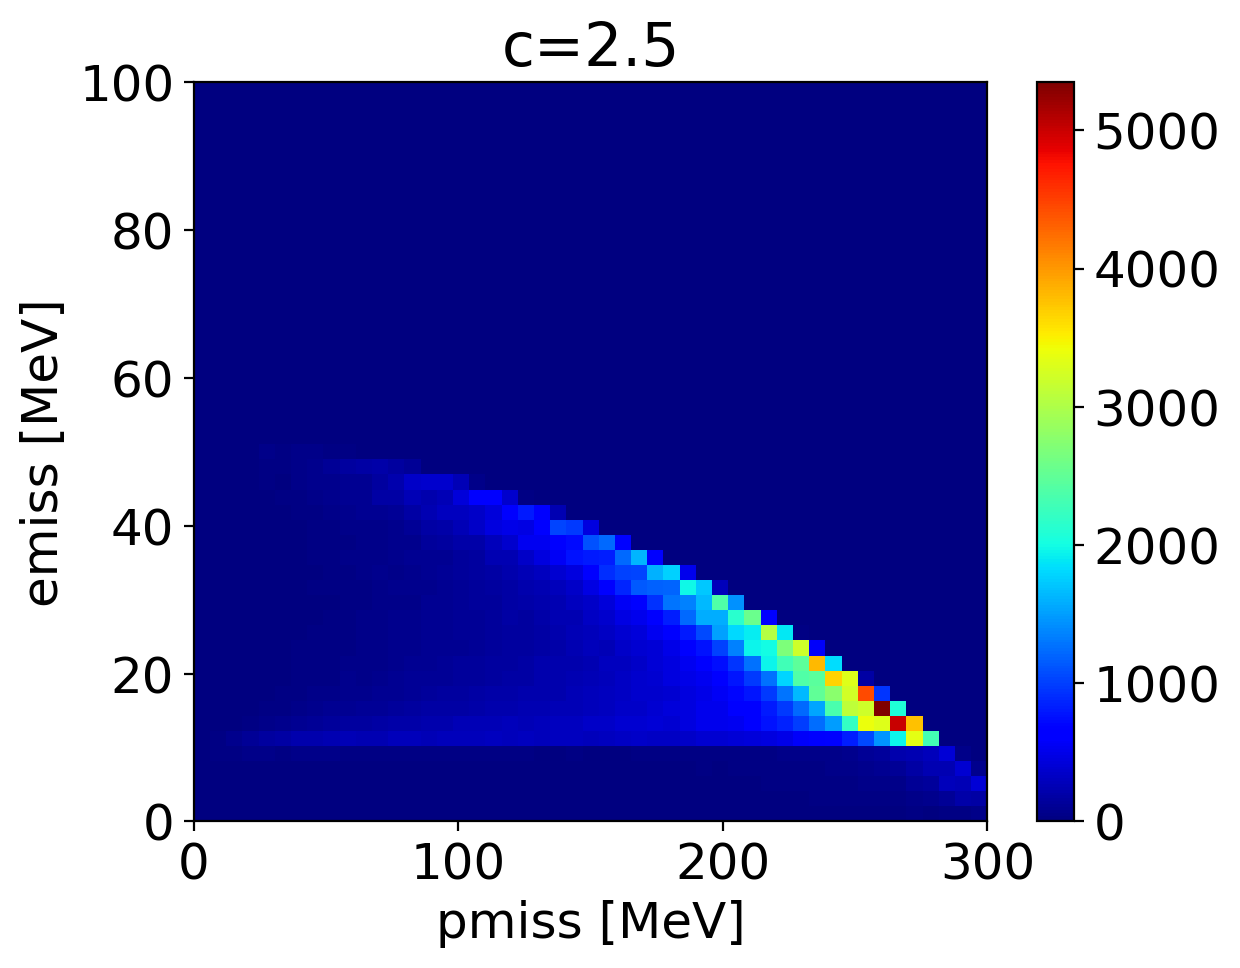

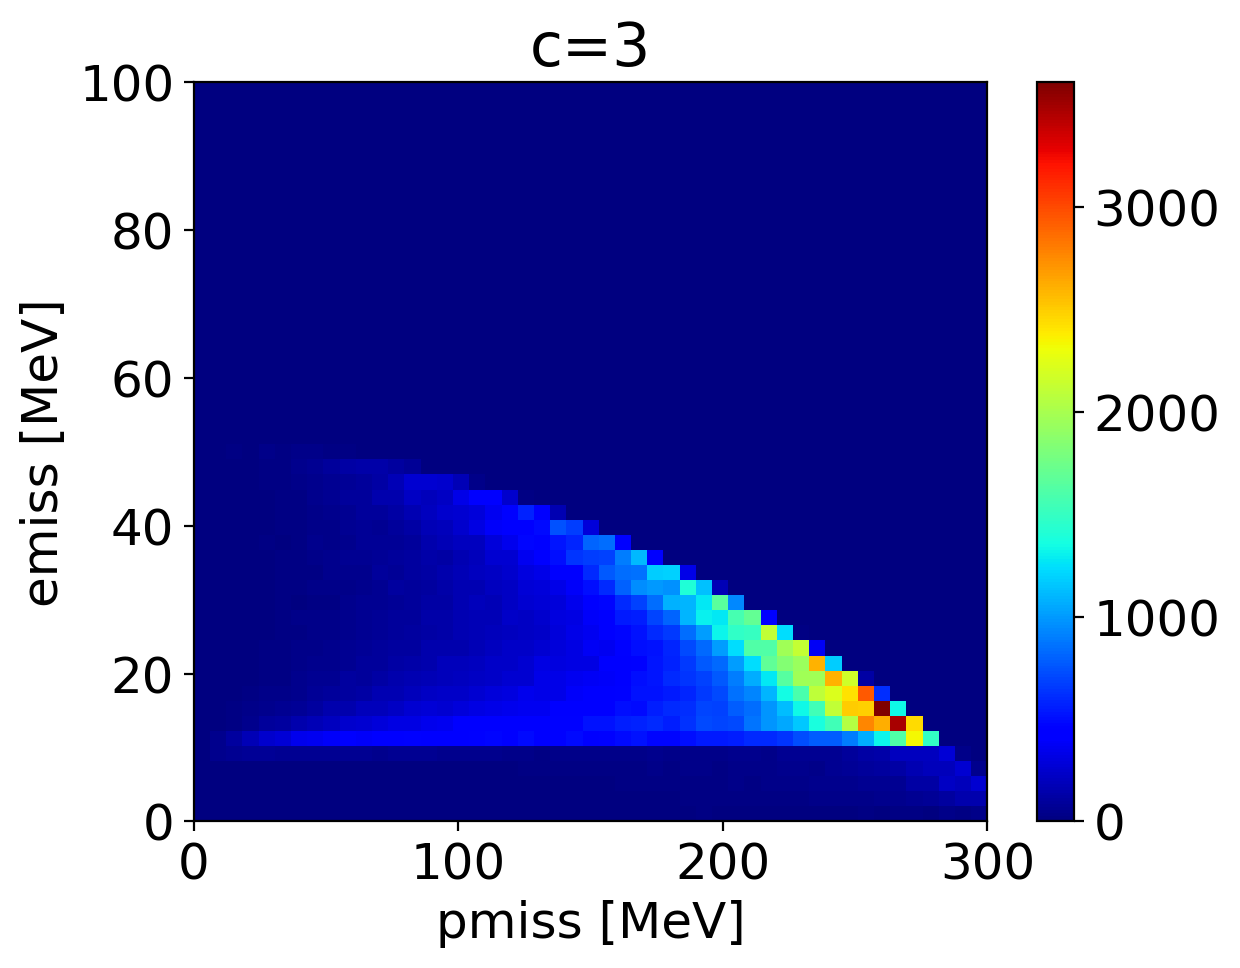

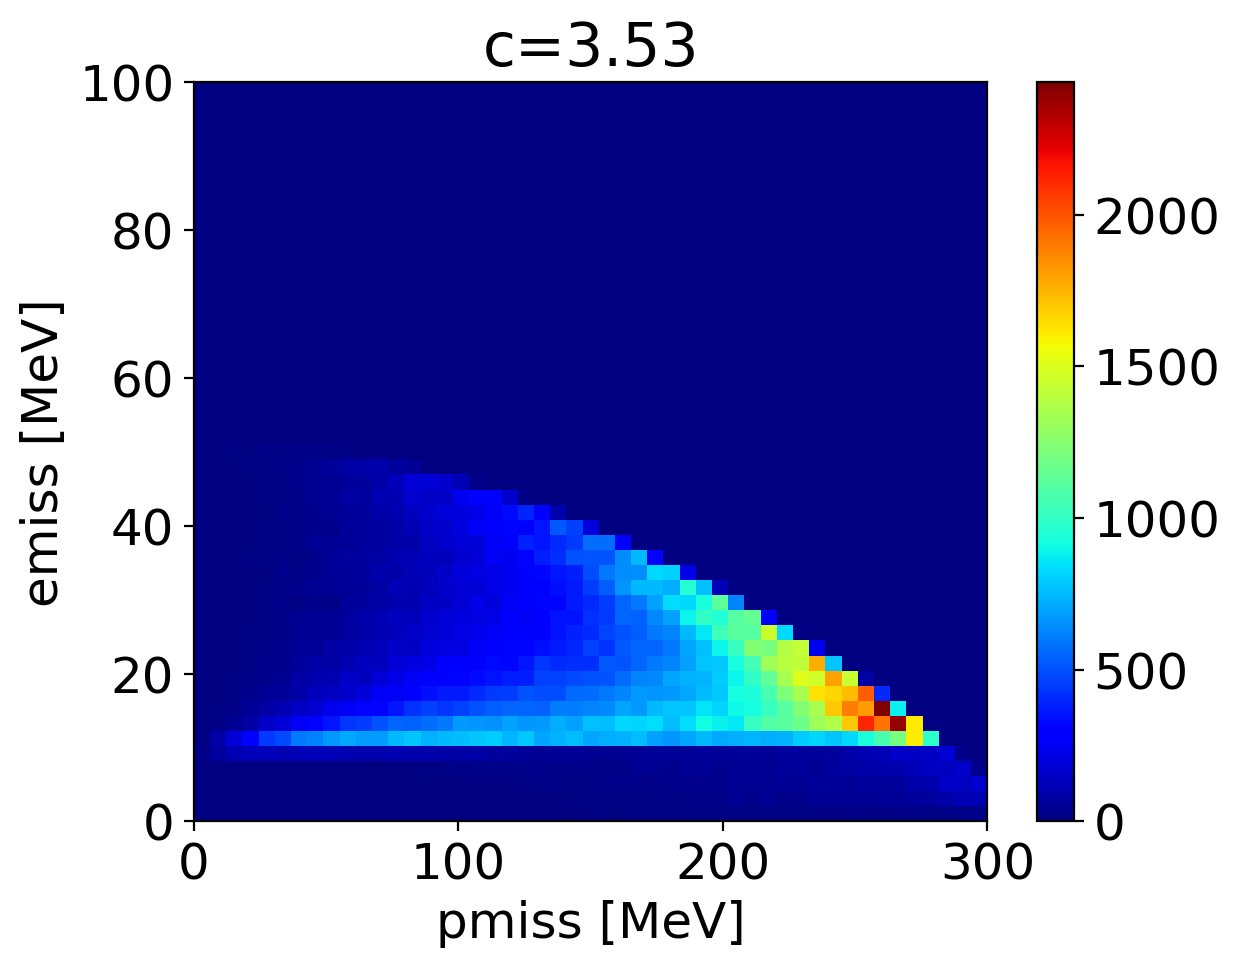

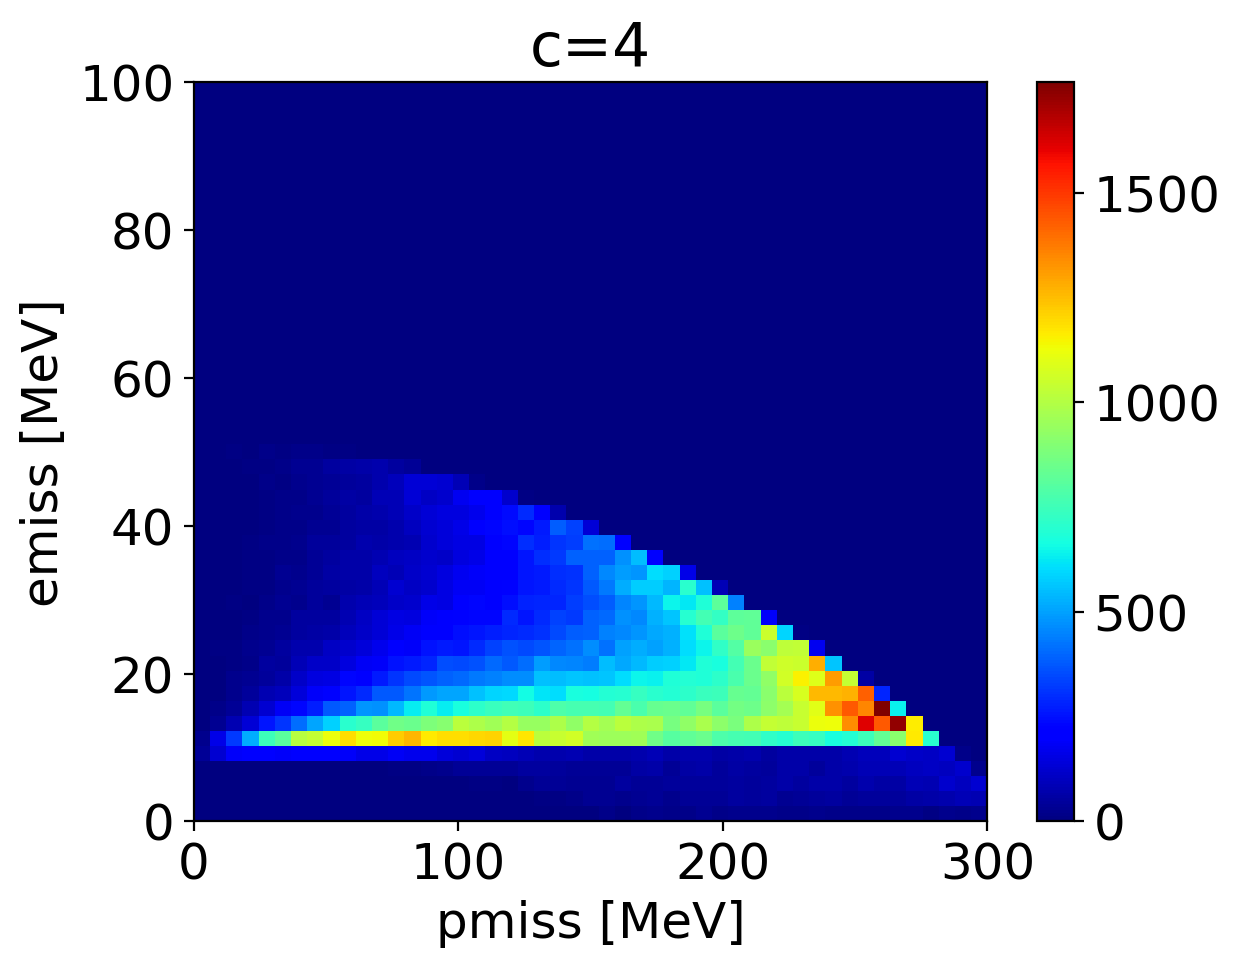

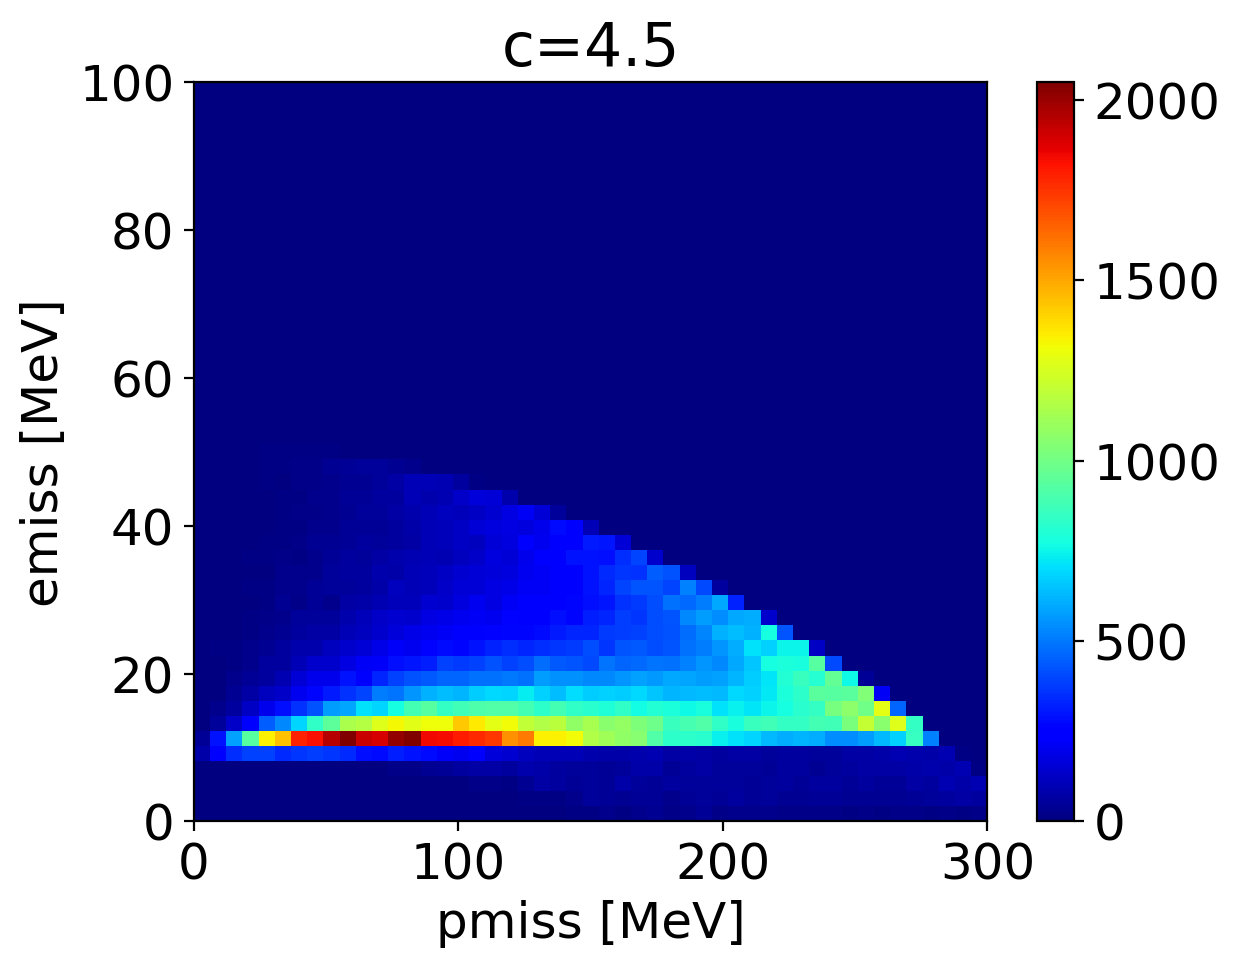

In [96]:
nucleon_mass = 0.93956542052
data = variations_ccqe.with_columns(
    pmiss = (pl.col('hitnuc_Px')**2 + pl.col('hitnuc_Py')**2 + pl.col('hitnuc_Pz')**2).sqrt(),
    emiss = nucleon_mass - pl.col('hitnuc_E') ,
)

pbins = np.linspace(0, 300, 50)
ebins = np.linspace(0, 100, 50)

cvals = [2.5, 3, 3.53, 4, 4.5]

for i in range(5):
    plt.figure()
    plt.hist2d(data['pmiss']*1000, data['emiss']*1000, bins=(pbins, ebins), cmap='jet', weights=data[f'nucleus_radius_{i}']);
    plt.xlabel('pmiss [MeV]')
    plt.ylabel('emiss [MeV]')
    plt.title(f'c={cvals[i]}')
    plt.colorbar()

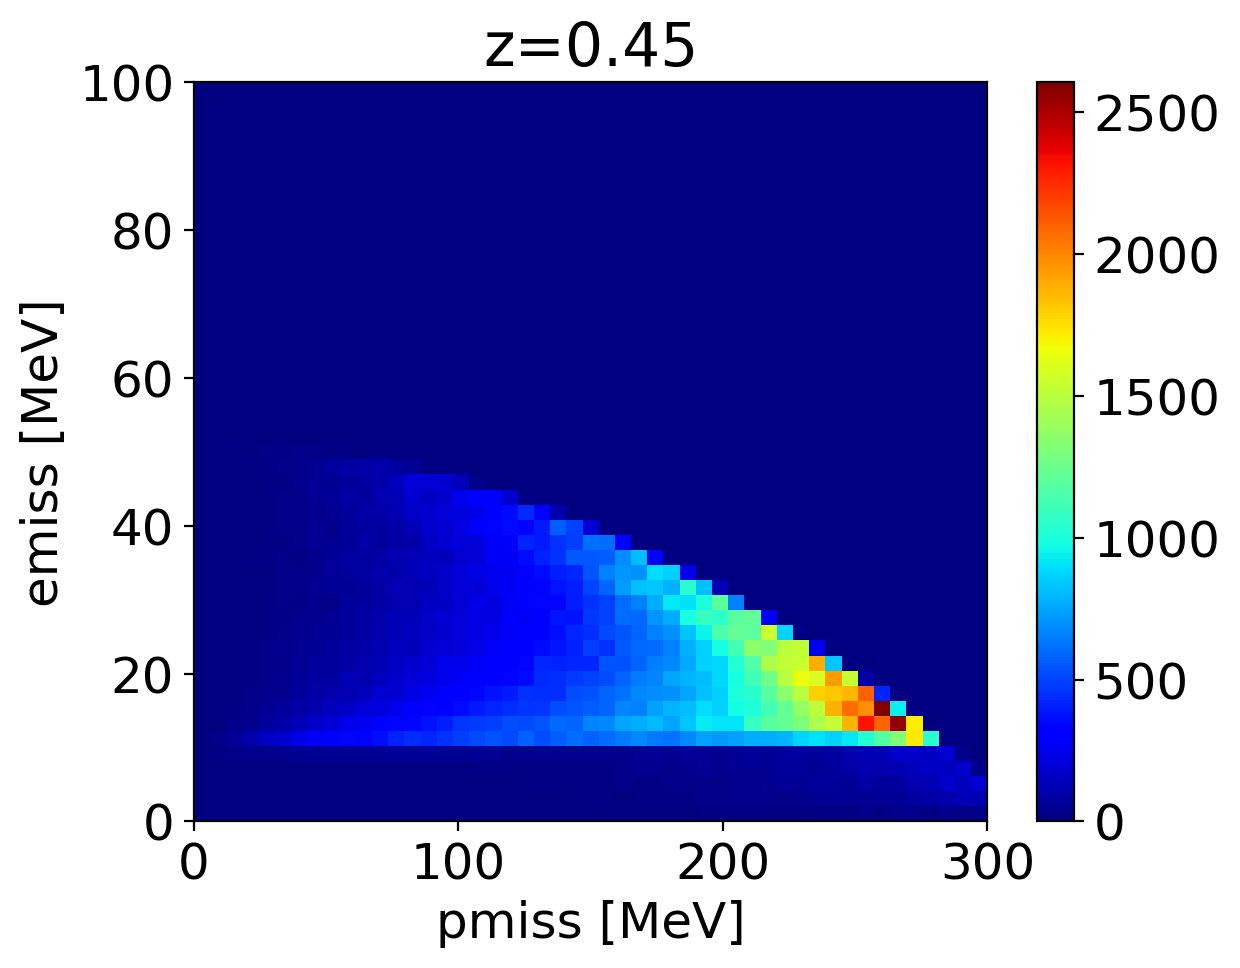

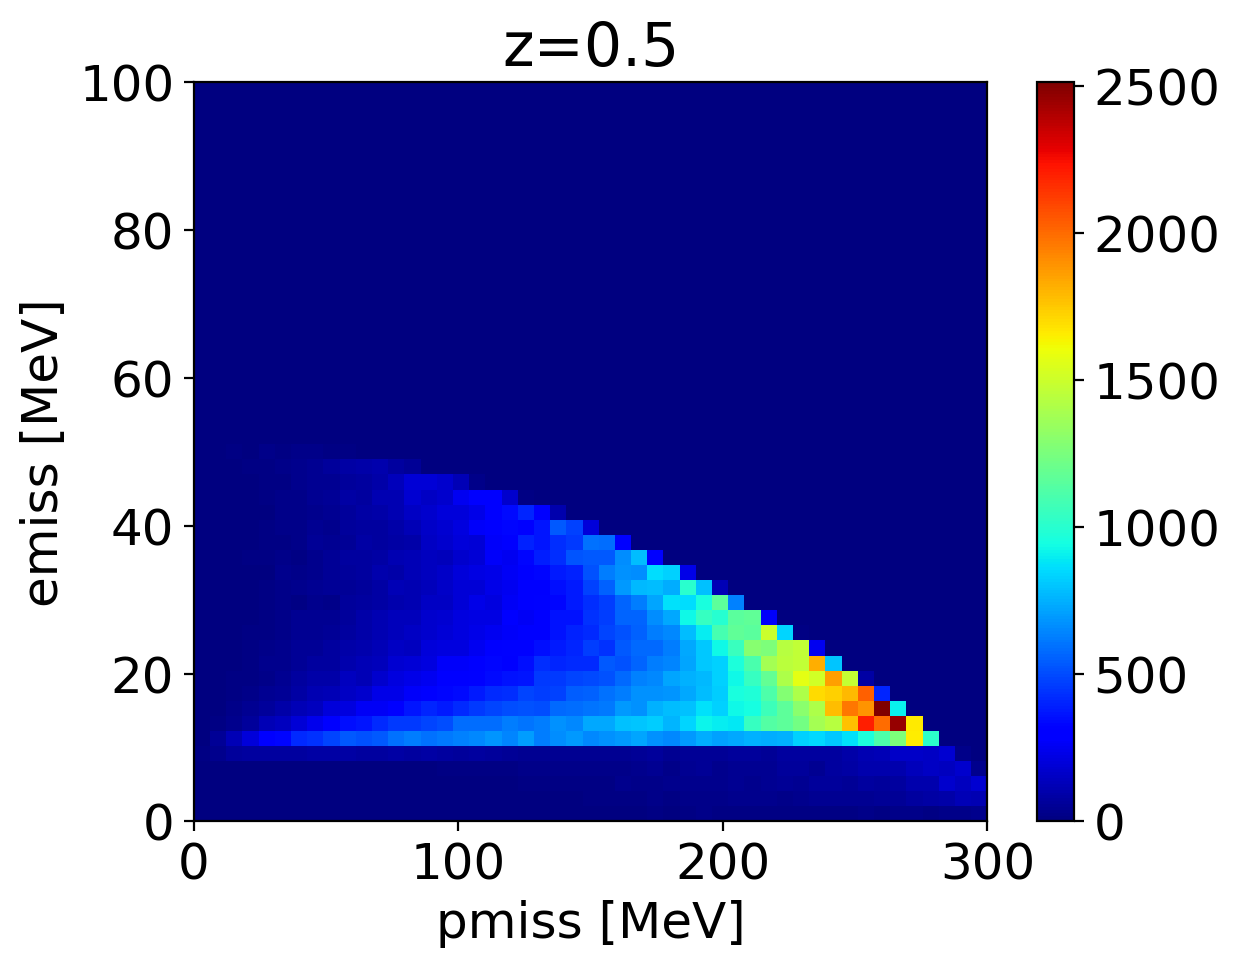

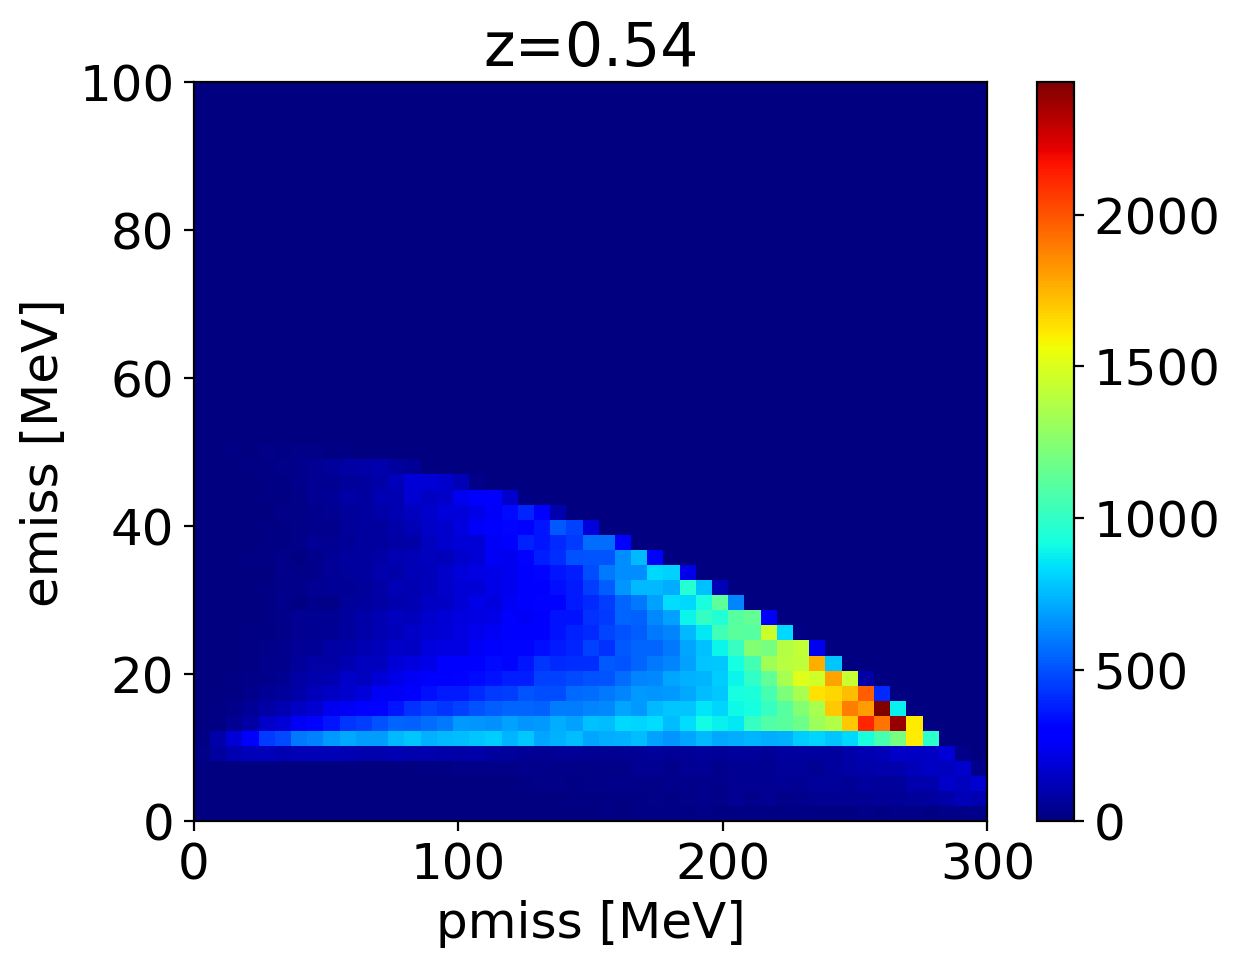

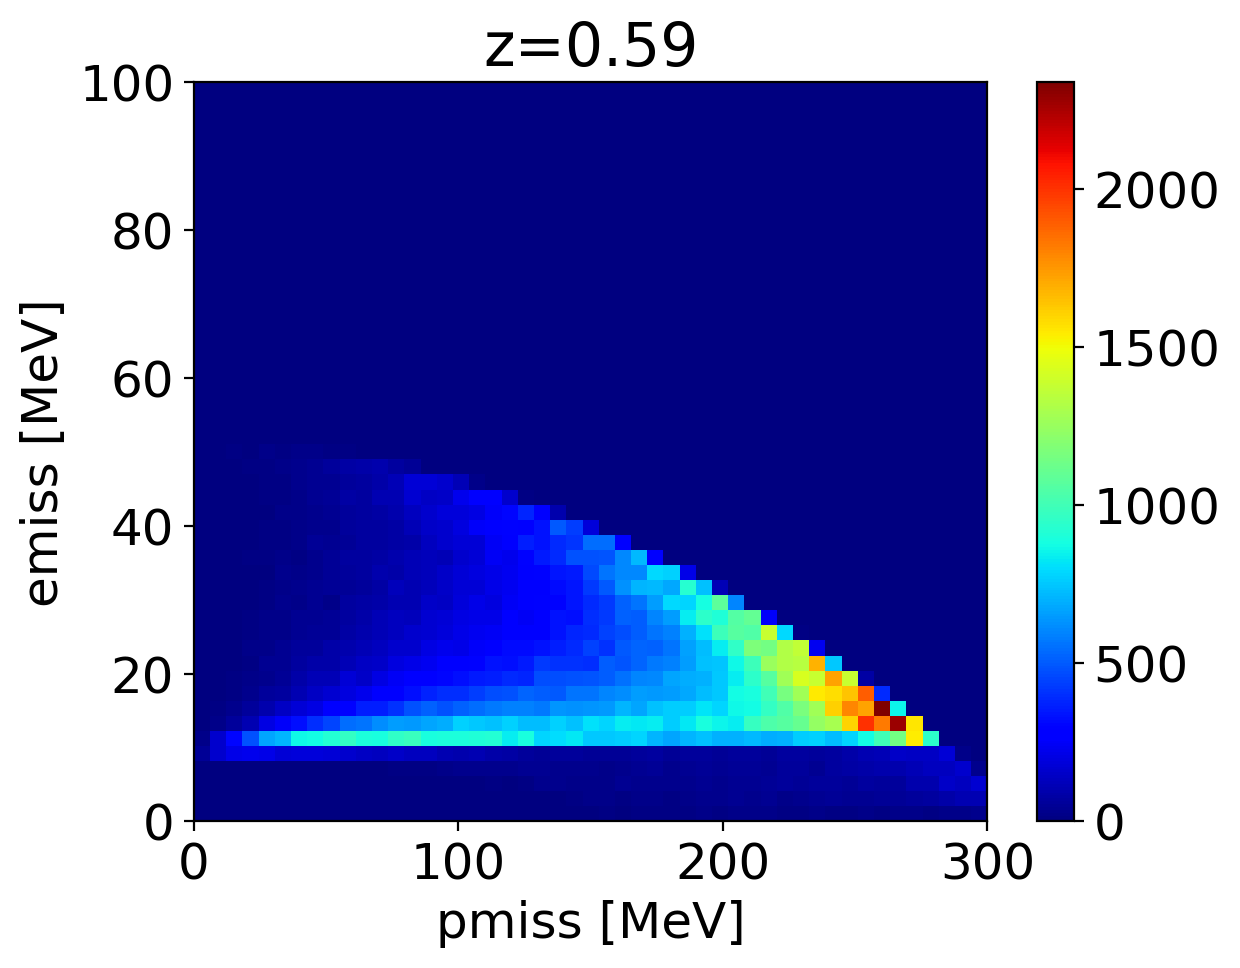

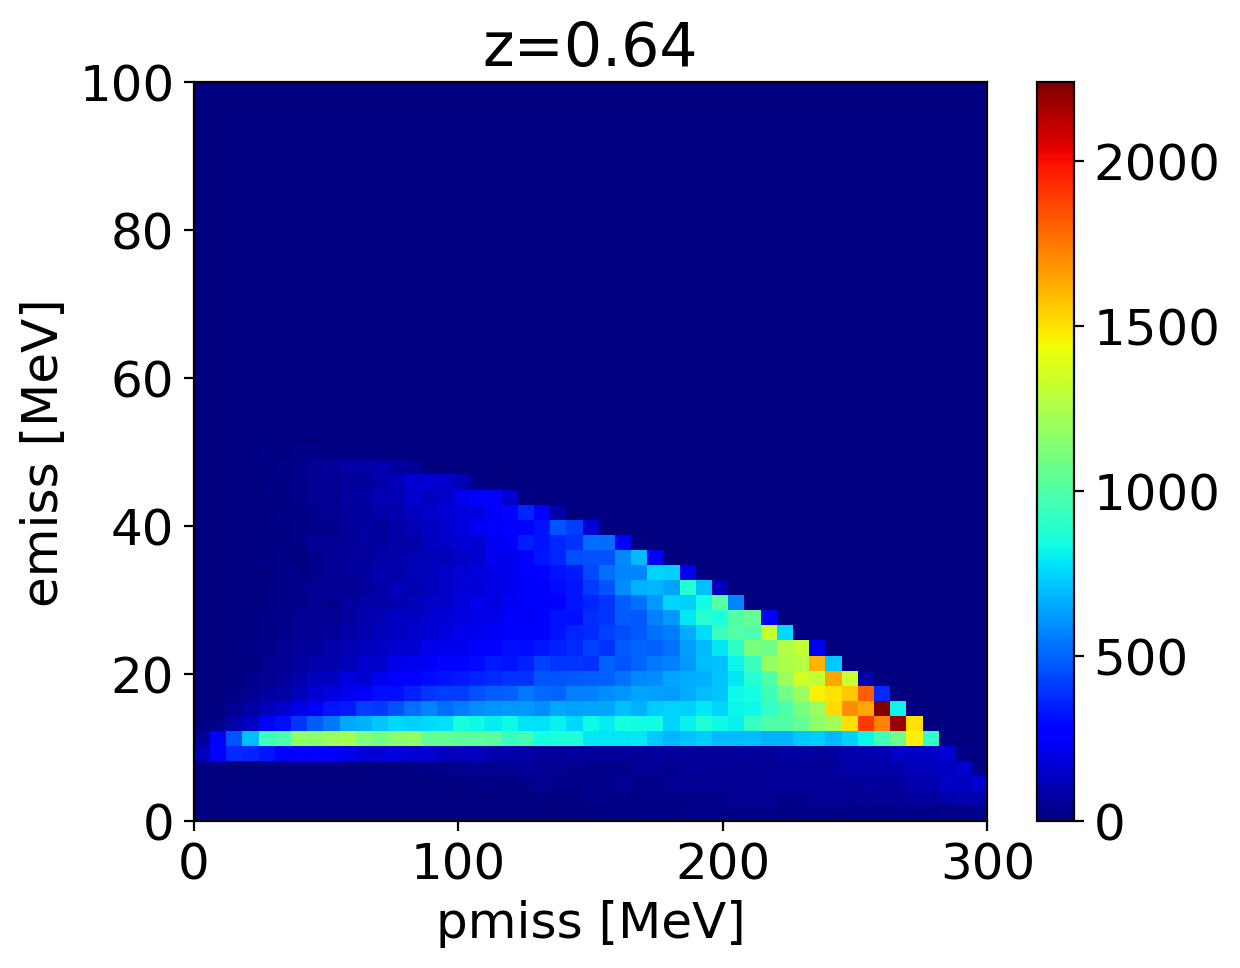

In [97]:
nucleon_mass = 0.93956542052
data = variations_ccqe.with_columns(
    pmiss = (pl.col('hitnuc_Px')**2 + pl.col('hitnuc_Py')**2 + pl.col('hitnuc_Pz')**2).sqrt(),
    emiss = nucleon_mass - pl.col('hitnuc_E') ,
)

pbins = np.linspace(0, 300, 50)
ebins = np.linspace(0, 100, 50)

zvals = [0.45, 0.5, 0.54, 0.59, 0.64]

for i in range(5):
    plt.figure()
    plt.hist2d(data['pmiss']*1000, data['emiss']*1000, bins=(pbins, ebins), cmap='jet', weights=data[f'surface_thickness_{i}']);
    plt.xlabel('pmiss [MeV]')
    plt.ylabel('emiss [MeV]')
    plt.title(f'z={zvals[i]}')
    plt.colorbar()

211901


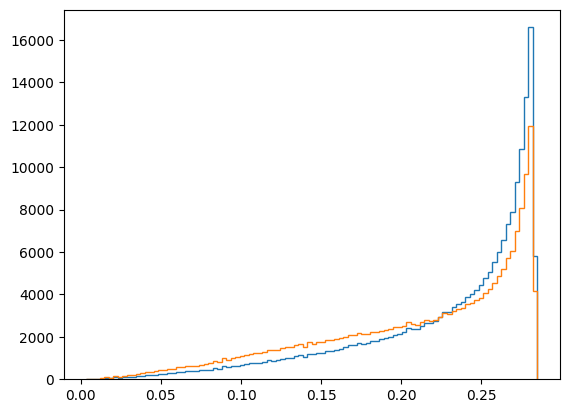

In [13]:
import uproot
import polars as pl
with uproot.open('WSReweightWeights_validTree.root') as f:
    data = f['valid_tree'].arrays(library='pd', filter_name=lambda x: not 'pmiss' in x)
data = pl.from_pandas(data)
ccqe = data.filter(pl.col('NEUTMode') == 1)
print(len(ccqe))
# plt.hist(ccqe['KF'], bins=100, histtype='step', label='KF');
# plt.hist(ccqe['Enu'], bins=np.linspace(0, 1), histtype='step', label='KF');
# plt.hist(ccqe['Emiss'], bins=200, histtype='step', label='KF');
# plt.hist(ccqe['radius'], bins=100, histtype='step', label='KF');
# plt.hist(ccqe['radius'], bins=100, histtype='step', label='KF', weights=ccqe['ref_prob_density']);
# plt.hist(ccqe['radius'], bins=100, histtype='step', label='KF', weights=ccqe['new_prob_density']/ccqe['ref_prob_density']);

plt.hist(ccqe['KF'], bins=100, histtype='step', label='KF');
plt.hist(ccqe['KF'], bins=100, histtype='step', label='KF', weights=ccqe['new_prob_density']/ccqe['ref_prob_density']);

In [7]:
relevant_systs = [
    "surface_thickness",
    "nucleus_radius",
]

from scipy.stats import binned_statistic


def plot_variations(data, syst, var, bins, logx=False, xlabel=None):
    
    plt.figure()
    nominal_index = systs_header.filter(pl.col('name') == syst)['nshifts'][0] // 2
    for idx in range(nominal_index - 1, nominal_index + 2):
        plt.hist(data.select(var), bins=bins, histtype='step', weights=data[f'{syst}_{idx}'], label=rf'{idx - nominal_index}$\sigma$', lw=2);
    if logx:
        plt.xscale('log')
    plt.legend(title=syst)
    if xlabel is not None:
        plt.xlabel(xlabel)
    else:
        plt.xlabel(var)
    plt.ylabel('# Events')
    plt.tight_layout()

def plot_variations_ratio(data, syst, var, bins, logx=False, xlabel=None):
    plt.figure()

    nominal_index = systs_header.filter(pl.col('name') == syst)['nshifts'][0] // 2
    events_var = data.select(var).to_numpy().T

    nominal = np.histogram(events_var[0], bins=bins, weights=data[f'{syst}_{nominal_index}'])[0]
    for idx in range(nominal_index - 1, nominal_index + 2):
        weights = data[f'{syst}_{idx}']
        hist = np.histogram(events_var[0], bins=bins, weights=weights)[0]
        plt.plot(bins[:-1], hist / nominal, label=rf'{idx - nominal_index:+d}$\sigma$', lw=2);
    if logx:
        plt.xscale('log')
    plt.legend(title=syst)
    if xlabel is not None:
        plt.xlabel(xlabel)
    else:
        plt.xlabel(var)
    plt.ylabel('Ratio to nominal')
    plt.tight_layout()

def plot_variations_2d(data, syst, var, bins, logx=False, logy=False, xlabel=None, ylabel=None, nb_sigmas=1):
    assert(len(var) == 2)
    assert(len(bins) == 2)
    plt.figure()

    nominal_index = systs_header.filter(pl.col('name') == syst)['nshifts'][0] // 2
    events_var = data.select(var).to_numpy().T

    nominal = np.histogram2d(events_var[0], events_var[1], bins=bins, weights=data[f'{syst}_{nominal_index}'])[0]
    assert(nominal_index + nb_sigmas < systs_header.filter(pl.col('name') == syst)['nshifts'][0])
    weights = data[f'{syst}_{nominal_index+nb_sigmas}']
    hist = np.histogram2d(events_var[0], events_var[1], bins=bins, weights=weights)[0]
    plt.pcolormesh(bins[0], bins[1], (hist / nominal).T, cmap='jet', shading='auto', alpha=1);
    plt.colorbar()
    # plt.imshow(hist / nominal, extent=[bins[0][0], bins[0][-1], bins[1][0], bins[1][-1]]);
    if logx:
        plt.xscale('log')
    if logy:
        plt.yscale('log')
    plt.legend(title=syst)
    if xlabel is not None:
        plt.xlabel(xlabel)
    else:
        plt.xlabel(var[0])
    if ylabel is not None:
        plt.ylabel(ylabel)
    else:
        plt.ylabel(var[1])
    plt.title(rf'({nb_sigmas:+}$\sigma$)Ratio to nominal')
    plt.tight_layout()

# def plot_variations_resolution(data, syst, var1, var2, bins, logx=False):
#     plt.figure()

#     def weighted_std(sample, weights):
#         return np.std(sample, weights=weights)

#     nominal_index = systs_header.filter(pl.col('name') == syst)['nshifts'][0] // 2
#     for idx in range(nominal_index - 1, nominal_index + 2):
#         weights = data[f'{syst}_{idx}'].to_numpy().flat
#         # std = binned_statistic(data.select(var1).to_numpy().flat, data.select(var2).to_numpy().flat, statistic='std', bins=bins).statistic
#         std = binned_statistic(data.select(var1).to_numpy().flat, data.select(var2).to_numpy().flat, statistic=lambda x: weighted_std(x, weights[np.in1d(data, x)]), bins=bins).statistic
#         plt.errorbar(0.5*(bins[:-1] + bins[1:]), std, fmt='o', label=rf'{idx - nominal_index}$\sigma$', lw=2)
#     if logx:
#         plt.xscale('log')
#     plt.legend(title=syst)
#     plt.xlabel(var1)
#     plt.ylabel(var2)
#     plt.tight_layout()

    

# plot_variations_ratio(cc_qe, "ZExpA1CCQE", 'nu_E', np.linspace(0.1, 1, 50),)
for param in tqdm(relevant_systs):
    nshifts = systs_header.filter(pl.col('name') == param)['nshifts'][0]
    if nshifts <= 2:
        continue
    fetched_data = data.with_columns(
        direc_true = pl.col('nu_Py')/pl.col('nu_E'),
        direc_reco = pl.when(pl.col('Pmu_y') != 0).then(pl.col('Pmu_y')).otherwise(pl.col('Pe_y')),
        pmiss = (pl.col('hitnuc_Px')**2 + pl.col('hitnuc_Py')**2 + pl.col('hitnuc_Pz')**2).sqrt()*1000,
    ).with_columns(
        direc_res = (pl.col('direc_reco').arccos() - pl.col('direc_true').arccos())*180/np.pi,
        Erec = pl.when(pl.col('pdg').abs() == 14).then(pl.col('Elep_calo')).otherwise(pl.col('Ee_calo')),
    ).filter(
        pl.col('direc_reco').abs() <= 1,
    )
    plot_variations(fetched_data, param, 'nu_E', np.linspace(0.1, 2, 50),)
    plt.savefig(f'plots/{param}_nu_E.png', dpi=300)
    plt.close()
    plot_variations_ratio(fetched_data, param, 'nu_E', np.linspace(0.1, 2, 50),)
    plt.savefig(f'plots/{param}_nu_E_ratio.png', dpi=300)
    plt.close()

    plot_variations(fetched_data, param, 'Q2', np.linspace(0, 2, 50),)
    plt.savefig(f'plots/{param}_Q2.png', dpi=300)
    plt.close()
    plot_variations_ratio(fetched_data, param, 'Q2', np.linspace(0, 2, 50),)
    plt.savefig(f'plots/{param}_Q2_ratio.png', dpi=300)
    plt.close()

    plot_variations(fetched_data, param, 'Erec', np.linspace(0.1, 2, 50),)
    plt.savefig(f'plots/{param}_Erec.png', dpi=300)
    plt.close()
    plot_variations_ratio(fetched_data, param, 'Erec', np.linspace(0.1, 2, 50),)
    plt.savefig(f'plots/{param}_Erec_ratio.png', dpi=300)
    plt.close()

    plot_variations(fetched_data, param, pl.col('nu_E') - pl.col('Erec'), np.linspace(0.1, 2, 50), xlabel='Enu - Erec')
    plt.savefig(f'plots/{param}_Eres.png', dpi=300)
    plt.close()
    plot_variations_ratio(fetched_data, param, pl.col('nu_E') - pl.col('Erec'), np.linspace(0.1, 2, 50), xlabel='Enu - Erec')
    plt.savefig(f'plots/{param}_Eres_ratio.png', dpi=300)
    plt.close()

    plot_variations(fetched_data, param, 1 - pl.col('Erec')/pl.col('nu_E'), np.linspace(-1, 1, 50), xlabel='1 - Erec/Enu')
    plt.savefig(f'plots/{param}_Eresrel.png', dpi=300)
    plt.close()
    plot_variations_ratio(fetched_data, param, 1 - pl.col('Erec')/pl.col('nu_E'), np.linspace(-1, 1, 50), xlabel='1 - Erec/Enu')
    plt.savefig(f'plots/{param}_Eresrel_ratio.png', dpi=300)
    plt.close()

    plot_variations_2d(fetched_data, param, ['q0', 'q3'] , [np.linspace(0, 1.5, 40), np.linspace(0, 1.5, 40)], nb_sigmas=1)
    plt.savefig(f'plots/{param}_2d_q0q3_+1_ratio.png', dpi=300)
    plt.close()
    plot_variations_2d(fetched_data, param, ['q0', 'q3'] , [np.linspace(0, 1.5, 40), np.linspace(0, 1.5, 40)], nb_sigmas=-1)
    plt.savefig(f'plots/{param}_2d_q0q3_-1_ratio.png', dpi=300)
    plt.close()

    plot_variations_2d(fetched_data, param, [1 - pl.col('Erec')/pl.col('nu_E'), 'direc_res'] , [np.linspace(-1, 1, 40), np.linspace(-180, 180, 40)], nb_sigmas=1, xlabel='1 - Erec/Enu')
    plt.savefig(f'plots/{param}_2d_EresThetares_+1_ratio.png', dpi=300)
    plt.close()
    plot_variations_2d(fetched_data, param, [1 - pl.col('Erec')/pl.col('nu_E'), 'direc_res'] , [np.linspace(-1, 1, 40), np.linspace(-180, 180, 40)], nb_sigmas=-1, xlabel='1 - Erec/Enu')
    plt.savefig(f'plots/{param}_2d_EresThetares_-1_ratio.png', dpi=300)
    plt.close()
    
    # plot_variations_2d(fetched_data, param, ['Erec', 'direc_res'] , [np.linspace(0.1, 2, 15), np.linspace(-2, 2, 15)],)
    # plt.savefig(f'plots/{param}_2d_ratio.png', dpi=300)
    # plt.close()
    # plot_variations_resolution(fetched_data, param, 'nu_E', 'direc_res', np.linspace(0.1, 2, 50),)
    # plt.savefig(f'plots/{param}_nu_E_dirRes.pdf')
    # plt.close()
    plot_variations(fetched_data, param, 'direc_res', np.linspace(-180, 180, 50),)
    plt.savefig(f'plots/{param}_dirRes.png', dpi=300)
    plt.close()
    plot_variations_ratio(fetched_data, param, 'direc_res', np.linspace(-180, 180, 50),)
    plt.savefig(f'plots/{param}_dirRes_ratio.png', dpi=300)
    plt.close()

# def plot_variations_resolution(data, syst, var1, var2, bins, logx=False):
#     plt.figure()

#     def weighted_std(sample, weights):
#         return np.std(sample, weights=weights)

#     nominal_index = systs_header.filter(pl.col('name') == syst)['nshifts'][0] // 2
#     for idx in range(nominal_index - 1, nominal_index + 2):
#         weights = data[f'{syst}_{idx}'].to_numpy().flat
#         # std = binned_statistic(data.select(var1).to_numpy().flat, data.select(var2).to_numpy().flat, statistic='std', bins=bins).statistic
#         std = binned_statistic(data.select(var1).to_numpy().flat, data.select(var2).to_numpy().flat, statistic=lambda x: weighted_std(x, weights[np.in1d(data, x)]), bins=bins).statistic
#         plt.errorbar(0.5*(bins[:-1] + bins[1:]), std, fmt='o', label=rf'{idx - nominal_index}$\sigma$', lw=2)
#     if logx:
#         plt.xscale('log')
#     plt.legend(title=syst)
#     plt.xlabel(var1)
#     plt.ylabel(var2)
#     plt.tight_layout()

    

# plot_variations_ratio(cc_qe, "ZExpA1CCQE", 'nu_E', np.linspace(0.1, 1, 50),)
# for param in tqdm(relevant_systs):
#     nshifts = systs_header.filter(pl.col('name') == param)['nshifts'][0]
#     if nshifts <= 2:
#         continue
#     fetched_data = data.with_columns(
#         direc_true = pl.col('nu_Py')/pl.col('nu_E'),
#         direc_reco = pl.when(pl.col('Pmu_y') != 0).then(pl.col('Pmu_y')).otherwise(pl.col('Pe_y')),
#         pmiss = (pl.col('hitnuc_Px')**2 + pl.col('hitnuc_Py')**2 + pl.col('hitnuc_Pz')**2).sqrt()*1000,
#     ).with_columns(
#         direc_res = (pl.col('direc_reco').arccos() - pl.col('direc_true').arccos())*180/np.pi,
#         Erec = pl.when(pl.col('pdg').abs() == 14).then(pl.col('Elep_calo')).otherwise(pl.col('Ee_calo')),
#     ).filter(
#         pl.col('direc_reco').abs() <= 1,
#     )
#     plot_variations(fetched_data, param, 'nu_E', np.linspace(0.1, 2, 50),)
#     plt.savefig(f'plots/{param}_nu_E.png', dpi=300)
#     plt.close()
#     plot_variations_ratio(fetched_data, param, 'nu_E', np.linspace(0.1, 2, 50),)
#     plt.savefig(f'plots/{param}_nu_E_ratio.png', dpi=300)
#     plt.close()
#     plot_variations(fetched_data, param, 'Erec', np.linspace(0.1, 2, 50),)
#     plt.savefig(f'plots/{param}_Erec.png', dpi=300)
#     plt.close()
#     plot_variations_ratio(fetched_data, param, 'Erec', np.linspace(0.1, 2, 50),)
#     plt.savefig(f'plots/{param}_Erec_ratio.png', dpi=300)
#     plt.close()
#     plot_variations_2d(fetched_data, param, ['Erec', 'direc_reco'] , [np.linspace(0.1, 2, 15), np.linspace(-1, 1, 15)],)
#     plt.savefig(f'plots/{param}_2d_ratio.png', dpi=300)
#     plt.close()
#     # plot_variations_resolution(fetched_data, param, 'nu_E', 'direc_res', np.linspace(0.1, 2, 50),)
#     # plt.savefig(f'plots/{param}_nu_E_dirRes.pdf')
#     # plt.close()
#     plot_variations(fetched_data, param, 'direc_res', np.linspace(-180, 180, 50),)
#     plt.savefig(f'plots/{param}_dirRes.png', dpi=300)
#     plt.close()
#     plot_variations_ratio(fetched_data, param, 'direc_res', np.linspace(-180, 180, 50),)
#     plt.savefig(f'plots/{param}_dirRes_ratio.png', dpi=300)
#     plt.close()
# # plot_variations(cc_qe, "ZExpA1CCQE", (pl.col('hitnuc_Px')**2 + pl.col('hitnuc_Py')**2 + pl.col('hitnuc_Pz')**2).sqrt(), np.linspace(0, 0.3, 50))
# # plot_variations_2d(cc_qe, "ZExpA1CCQE", [nucleon_mass - pl.col('hitnuc_E'), (pl.col('hitnuc_Px')**2 + pl.col('hitnuc_Py')**2 + pl.col('hitnuc_Pz')**2).sqrt()], [np.linspace(0, 0.1, 50), np.linspace(0, 0.3, 50)])

  0%|          | 0/2 [00:00<?, ?it/s]/tmp/ipykernel_279384/1625177231.py:58: RuntimeWarning: invalid value encountered in divide
  plt.pcolormesh(bins[0], bins[1], (hist / nominal).T, cmap='jet', shading='auto', alpha=1);
/tmp/ipykernel_279384/1625177231.py:65: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=syst)
/tmp/ipykernel_279384/1625177231.py:35: RuntimeWarning: invalid value encountered in divide
  plt.plot(bins[:-1], hist / nominal, label=rf'{idx - nominal_index:+d}$\sigma$', lw=2);
100%|██████████| 2/2 [00:05<00:00,  2.83s/it]


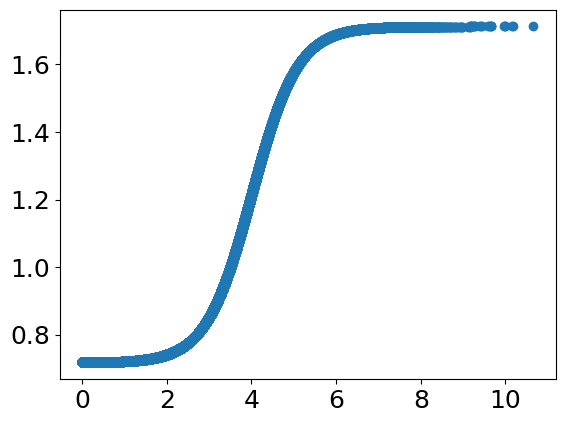

In [45]:
plt.scatter(ccqe['radius'], ccqe['new_prob_density']/ccqe['ref_prob_density']);

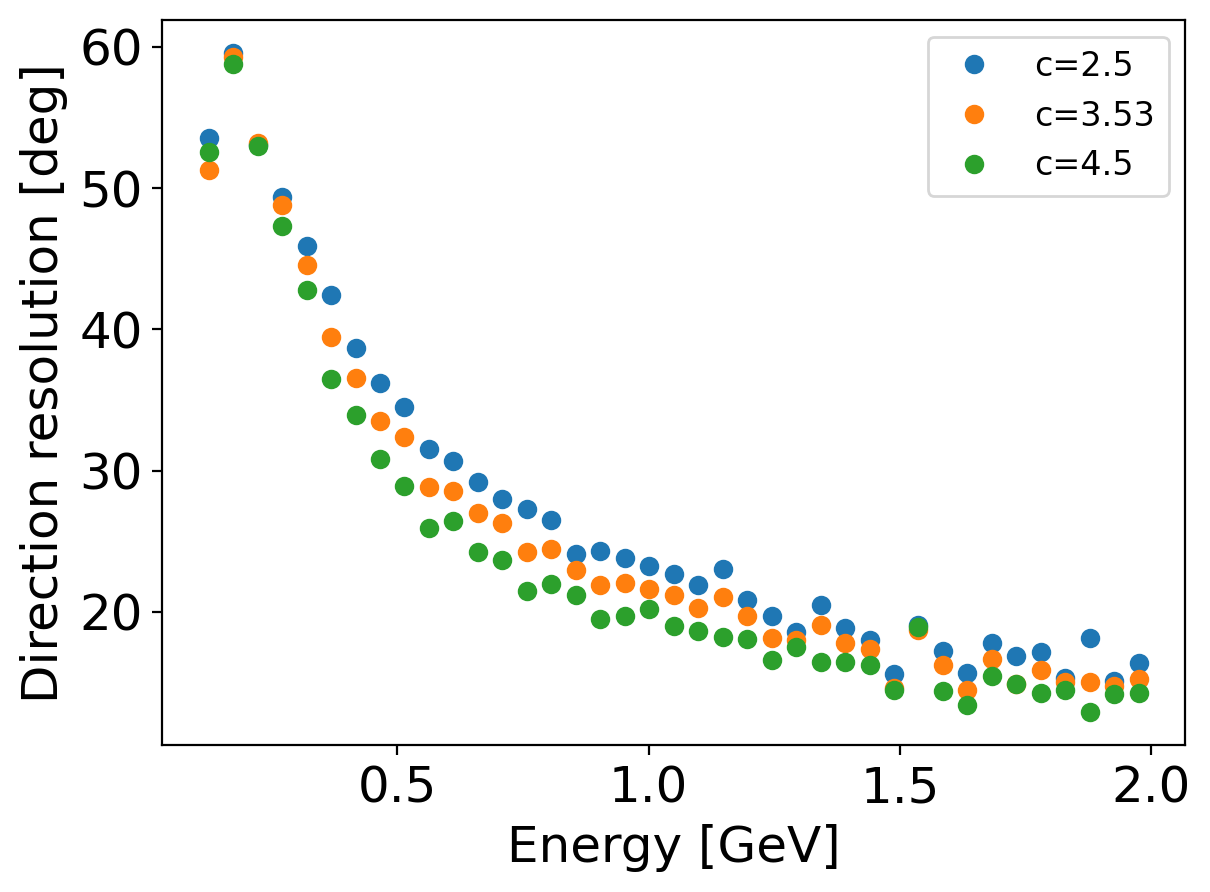

In [126]:
from scipy.stats import binned_statistic

numu_ccqe = data.filter(
    pl.col('pdg') == 14
).with_columns(
    direc_true = pl.col('nu_Py')/pl.col('nu_E'),
    direc_reco = pl.col('Pmu_y'),
    pmiss = (pl.col('hitnuc_Px')**2 + pl.col('hitnuc_Py')**2 + pl.col('hitnuc_Pz')**2).sqrt()*1000,
).with_columns(
    direc_res = (pl.col('direc_reco').arccos() - pl.col('direc_true').arccos())*180/np.pi
).filter(
    pl.col('direc_reco').abs() <= 1,
)

#Plotting the direction reco as a function of energy
Ebins = np.linspace(0.1, 2, 40)
Ecenters = 0.5*(Ebins[:-1] + Ebins[1:])

def manual_std(data:np.ndarray, quant=[0.16,0.84], weights=None) -> float:
    if len(data) == 0:
        return 0
    a, b = np.quantile(data, quant, method='inverted_cdf', weights=weights)
    return (b - a)/2

#Rewrite binned statistic to allow for weighted std
def binned_statistic_weighted(x, values, bins=10, weights=None):
    bin_count, bin_edges, binnumber = binned_statistic(x, values, statistic='count', bins=bins)
    bin_width = (bin_edges[1] - bin_edges[0])
    bin_centers = bin_edges[1:] - bin_width/2
    # print(bin_edges)
    bin_std = np.array([manual_std(values[binnumber == i], weights=weights[binnumber == i]) for i in range(1, len(bin_edges))])
    return bin_std, bin_centers

std, _ = binned_statistic_weighted(numu_ccqe['nu_E'].to_numpy(), numu_ccqe['direc_res'].to_numpy(), bins=Ebins, weights=numu_ccqe['nucleus_radius_0'].to_numpy())
plt.errorbar(Ecenters, std, fmt='o', label='c=2.5')

std, _ = binned_statistic_weighted(numu_ccqe['nu_E'].to_numpy(), numu_ccqe['direc_res'].to_numpy(), bins=Ebins, weights=numu_ccqe['nucleus_radius_2'].to_numpy())
plt.errorbar(Ecenters, std, fmt='o', label='c=3.53')

std, _ = binned_statistic_weighted(numu_ccqe['nu_E'].to_numpy(), numu_ccqe['direc_res'].to_numpy(), bins=Ebins, weights=numu_ccqe['nucleus_radius_4'].to_numpy())
plt.errorbar(Ecenters, std, fmt='o', label='c=4.5')

plt.xlabel('Energy [GeV]')
plt.ylabel('Direction resolution [deg]')
plt.legend(fontsize=12)
plt.tight_layout()